# Predicción de Supervivencia en el Titanic usando PCA y Agrupamiento con K-Means y GMM (Semana 3)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 3 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

1. **Fase I — Preprocesamiento:** carga, limpieza, imputación, codificación y detección de atípicos.
2. **Fase II — EDA:** balance de clases, correlaciones y selección de características.
3. **Fase III — Reducción de dimensionalidad + Clasificación:** se entrena cada uno de los **8 algoritmos
   de clasificación** ya estudiados en versión **original (Standard)**, con **PCA** y con **LDA**, para
   comparar las métricas *con* y *sin* reducción de dimensiones.
4. **Fase IV — Agrupamiento (no supervisado):** se aplican **K-Means** y **GMM** con `k = 2, 3 y 4`, y se
   comparan con las métricas de clustering: **inercia, coeficiente de silueta, Calinski-Harabasz y
   Davies-Bouldin**.

> **Clase positiva = `survived = 1` (Sobrevivió).** Priorizamos el **Recall**: el Falso Negativo
> (predecir que no sobrevivió alguien que sí podía) es el error más costoso en un contexto de rescate.

## 1. Configuración del entorno y carga de librerías

Se fija una **semilla global (`SEED = 42`)** en todas las funciones que la admitan para garantizar
la reproducibilidad de los resultados (divisiones, búsquedas de hiperparámetros, inicialización de clústeres, etc.).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia logs de TensorFlow
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# tensorflow solo se usa para una comprobación de tipo en evaluate(); si no está, se ignora
try:
    import tensorflow as tf
except Exception:
    tf = None

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Paleta del equipo
COLOR_NEG = "#2a9d8f"   # No sobrevivió (clase negativa)
COLOR_POS = "#e76f51"   # Sobrevivió (clase positiva)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas (no hardcodear absolutas)
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
DATA_DIR = PROJ_DIR / "data"
MODELS_DIR.mkdir(exist_ok=True); OUT_DIR.mkdir(exist_ok=True)

# Etiquetas legibles del objetivo
LABELS = {1: "Sobrevivió", 0: "No sobrevivió"}

print("Librerías cargadas. SEED =", SEED)

I0000 00:00:1782733471.577049    7720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Librerías cargadas. SEED = 42


I0000 00:00:1782733472.482672    7720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


---
# Fase I — Preprocesamiento

El Titanic es un dataset "sucio" (valores nulos, variables categóricas y columnas redundantes), por lo
que el preprocesamiento requiere más esfuerzo que en el dataset clínico.

## 2. Carga del dataset y exploración inicial

Usamos la versión del Titanic incluida en `seaborn` (idéntica a la clásica de Kaggle en variables
esenciales). Si no hubiese conexión, se intenta leer una copia local en `data/titanic_seaborn.csv`.

In [2]:
try:
    df = sns.load_dataset("titanic")
except Exception:
    df = pd.read_csv(DATA_DIR / "titanic_seaborn.csv")

print(f"Dimensiones: {df.shape[0]} pasajeros x {df.shape[1]} columnas")
print("\nDistribución de la clase objetivo (survived):")
print(df["survived"].map(LABELS).value_counts())
print("\nTipos de datos:")
print(df.dtypes)
df.head()

Dimensiones: 891 pasajeros x 15 columnas

Distribución de la clase objetivo (survived):
survived
No sobrevivió    549
Sobrevivió       342
Name: count, dtype: int64

Tipos de datos:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Separación de columnas irrelevantes o redundantes

Eliminamos columnas que son **duplicados** de otras (`alive` ≡ `survived`, `class` ≡ `pclass`,
`embark_town` ≡ `embarked`, `who`/`adult_male` derivan de `sex`/`age`), `alone` (deriva de
`sibsp`+`parch`) y `deck` (más del 75 % de valores nulos).

In [3]:
cols_drop = ["alive", "class", "embark_town", "who", "adult_male", "alone", "deck"]
df_clean = df.drop(columns=[c for c in cols_drop if c in df.columns]).copy()
print("Columnas conservadas:", list(df_clean.columns))

Columnas conservadas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


## 4. Verificación y tratamiento de valores perdidos

- **`age`:** se imputa con la **mediana por grupo de supervivencia** (más informativa que la mediana global).
- **`embarked`:** se imputa con la **moda** (solo faltan 2 registros).
- **`fare`:** se imputa con la **mediana** por robustez frente a atípicos.

In [4]:
print("Nulos ANTES de imputar:")
print((df_clean.isnull().sum()[lambda s: s > 0]).to_string())

df_clean["age"] = df_clean.groupby("survived")["age"].transform(lambda s: s.fillna(s.median()))
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
df_clean["fare"] = df_clean["fare"].fillna(df_clean["fare"].median())

print(f"\nNulos DESPUÉS de imputar: {int(df_clean.isnull().sum().sum())}")

Nulos ANTES de imputar:
age         177
embarked      2

Nulos DESPUÉS de imputar: 0


## 5. Codificación de variables categóricas

- `sex` → binaria (`male=0`, `female=1`).
- `embarked` → *one-hot encoding* (`drop_first=True` para evitar multicolinealidad perfecta).

In [5]:
df_clean["sex"] = df_clean["sex"].map({"male": 0, "female": 1})
df_clean = pd.get_dummies(df_clean, columns=["embarked"], drop_first=True, dtype=int)

feature_cols = [c for c in df_clean.columns if c != "survived"]
print(f"Variables predictoras ({len(feature_cols)}): {feature_cols}")
df_clean.head()

Variables predictoras (8): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


## 6. Detección de valores atípicos (IQR)

Cuantificamos los atípicos mediante el rango intercuartílico, pero **no los eliminamos a ciegas**:
en el Titanic, tarifas (`fare`) o tamaños de familia altos son señal legítima, no errores de medición.

In [6]:
def iqr_outlier_mask(frame, cols):
    # Devuelve (mascara booleana True=fila con >=1 atipico IQR, dict de conteos por columna)
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

iqr_cols = ["age", "fare", "sibsp", "parch"]
outlier_mask, outlier_counts = iqr_outlier_mask(df_clean, iqr_cols)
print(f"Filas con >=1 atípico IQR: {int(outlier_mask.sum())} de {len(df_clean)} "
      f"({100*outlier_mask.mean():.1f}%)")
print("\nAtípicos por variable:")
print(pd.Series(outlier_counts).sort_values(ascending=False))

Filas con >=1 atípico IQR: 314 de 891 (35.2%)

Atípicos por variable:
parch    213
fare     116
age       66
sibsp     46
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

## 7. Distribución de la variable objetivo (balance de clases)

El Titanic presenta un **desbalance moderado**: aproximadamente 62 % no sobrevivió / 38 % sobrevivió.

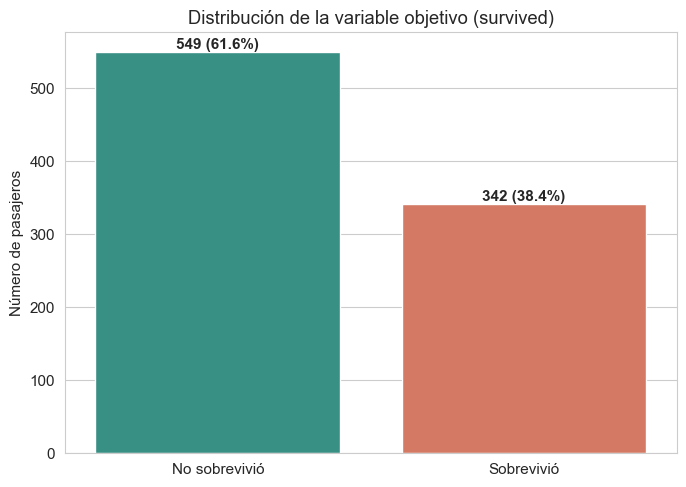

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_clean["survived"].map(LABELS).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=[COLOR_NEG, COLOR_POS], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df_clean):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (survived)")
ax.set_ylabel("Número de pasajeros"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=120); plt.show()

## 8. Estadística descriptiva de las variables numéricas relevantes

In [8]:
df_clean.groupby("survived")[["age", "fare", "sibsp", "parch"]].describe().T.round(2)

survived          0       1
age   count  549.00  342.00
      mean    30.03   28.29
      std     12.50   13.76
      min      1.00    0.42
      25%     23.00   21.00
      50%     28.00   28.00
      75%     35.00   35.00
      max     74.00   80.00
fare  count  549.00  342.00
      mean    22.12   48.40
      std     31.39   66.60
      min      0.00    0.00
      25%      7.85   12.48
      50%     10.50   26.00
      75%     26.00   57.00
      max    263.00  512.33
sibsp count  549.00  342.00
      mean     0.55    0.47
      std      1.29    0.71
      min      0.00    0.00
      25%      0.00    0.00
      50%      0.00    0.00
      75%      1.00    1.00
      max      8.00    4.00
parch count  549.00  342.00
      mean     0.33    0.46
      std      0.82    0.77
      min      0.00    0.00
      25%      0.00    0.00
      50%      0.00    0.00
      75%      0.00    1.00
      max      6.00    5.00

## 9. Correlación con el objetivo y selección de características

Calculamos la correlación de Pearson de cada predictora con `survived` y seleccionamos las que superan
un **umbral de |r| > 0.2** (en el Titanic las correlaciones son más débiles que en el dataset clínico).

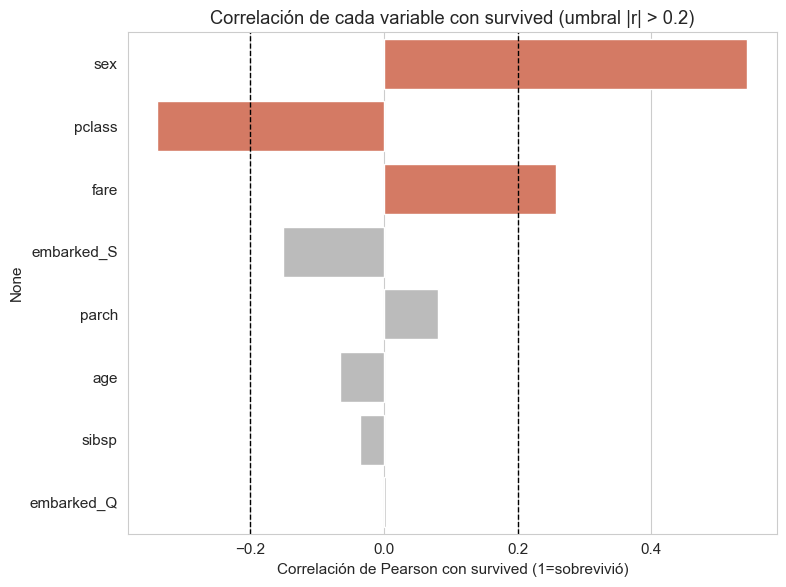

Variables seleccionadas (|r| > 0.2): ['sex', 'pclass', 'fare']
  sex            r = +0.543
  pclass         r = -0.338
  fare           r = +0.257


In [9]:
corr_target = df_clean.corr(numeric_only=True)["survived"].drop("survived").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.2
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [COLOR_POS if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con survived (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con survived (1=sobrevivió)")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {selected_features}")
for f in selected_features:
    print(f"  {f:<14} r = {corr_target[f]:+.3f}")

## 10. Histogramas de las variables más predictivas (por clase)

`sex` es la variable más predictiva (las mujeres sobrevivieron en mayor proporción), seguida de
`pclass` y `fare`.

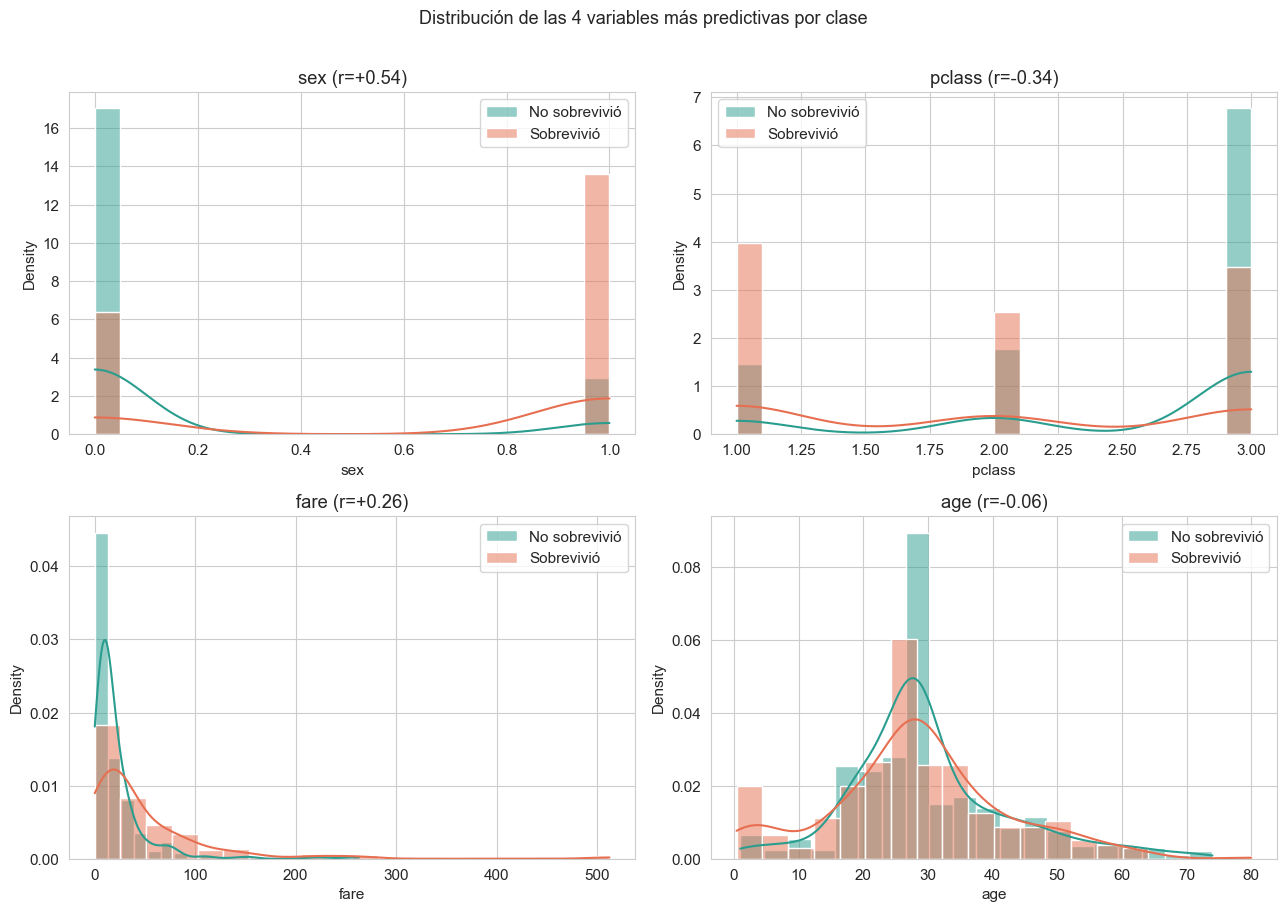

In [10]:
top4 = (selected_features + [c for c in feature_cols if c not in selected_features])[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(0, COLOR_NEG), (1, COLOR_POS)]:
        sns.histplot(df_clean[df_clean.survived == cls][col], ax=ax, color=color,
                     label=LABELS[cls], kde=True, stat="density", alpha=0.5, bins=20)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "03_histogramas_top.png", dpi=120); plt.show()

## 11. Boxplots para detección visual de atípicos

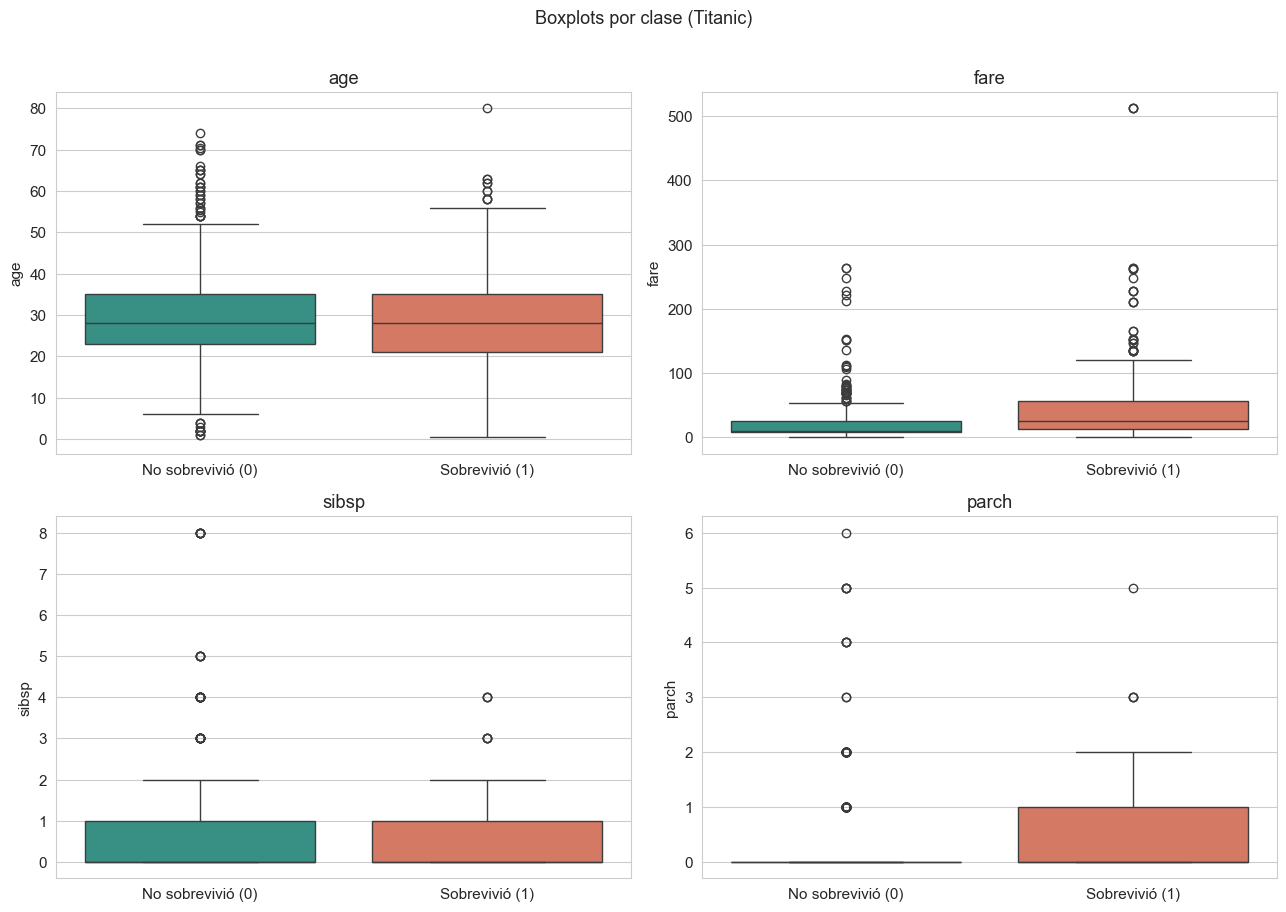

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ["age", "fare", "sibsp", "parch"]):
    sns.boxplot(data=df_clean, x="survived", y=col, palette=[COLOR_NEG, COLOR_POS], ax=ax)
    ax.set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"])
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots por clase (Titanic)", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_boxplots.png", dpi=120); plt.show()

## 12. Matriz de correlación entre predictoras (multicolinealidad)

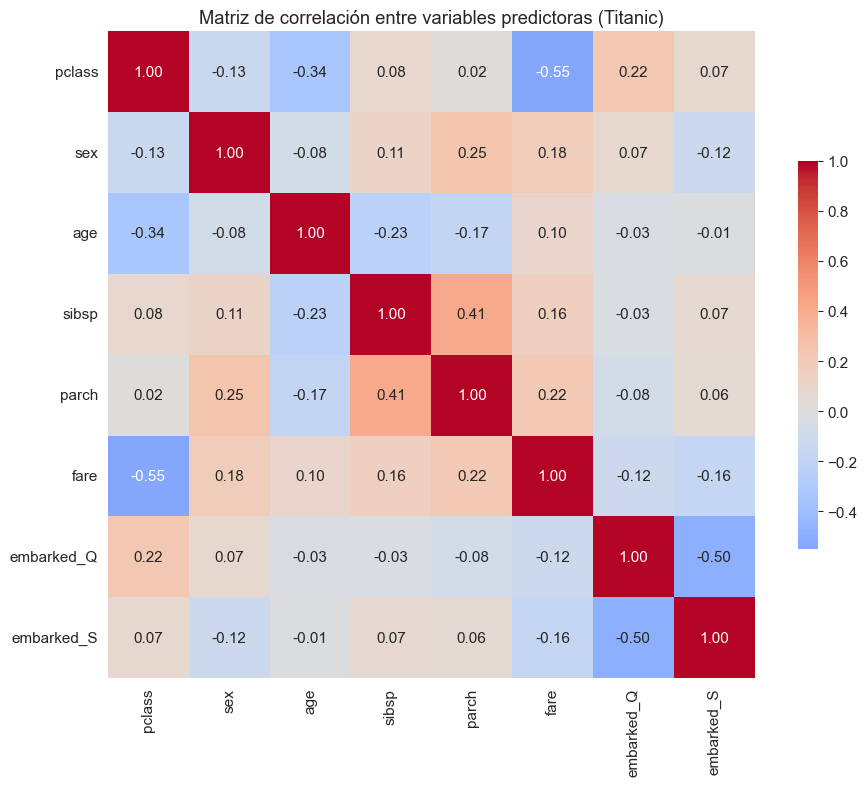

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean[feature_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras (Titanic)")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_heatmap_correlacion.png", dpi=120); plt.show()

### Conclusiones del EDA

- **Balance:** desbalance moderado (~62 % no sobrevivió / ~38 % sobrevivió), no requiere remuestreo.
- **Variables más predictivas:** `sex` (la más fuerte), `pclass` y `fare`.
- **Multicolinealidad:** `pclass` y `fare` están correlacionadas (clases altas pagaban más).
- **Separabilidad:** menor que en el dataset clínico → se espera un **dataset más complejo** y métricas
  más bajas.

---
# Fase III — Reducción de Dimensiones y Modelado

Entrenamos los **8 algoritmos de clasificación** ya estudiados, cada uno en **tres versiones**:
características originales (**Standard**), reducidas con **PCA** y reducidas con **LDA**. Así comparamos
el desempeño *con* y *sin* reducción de dimensionalidad. Mantenemos un **test intacto (20 %)** con
división **estratificada** y `random_state=42`.

## 13. División train/test, escalado y validación cruzada

In [13]:
X = df_clean[feature_cols].copy()
y = df_clean["survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Balance train: {dict(y_train.map(LABELS).value_counts())}")
print(f"Balance test : {dict(y_test.map(LABELS).value_counts())}")

# Escaladores ajustados SOLO con train (evita fuga de información)
std_scaler = StandardScaler().fit(X_train)
mm_scaler  = MinMaxScaler().fit(X_train)
X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

sel_idx = [feature_cols.index(f) for f in selected_features]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Variables seleccionadas: {selected_features} (índices {sel_idx})")

Train: 712 | Test: 179
Balance train: {'No sobrevivió': np.int64(439), 'Sobrevivió': np.int64(273)}
Balance test : {'No sobrevivió': np.int64(110), 'Sobrevivió': np.int64(69)}
Variables seleccionadas: ['sex', 'pclass', 'fare'] (índices [1, 0, 5])


## 14. Experimento: StandardScaler vs MinMaxScaler

Comparamos ambos normalizadores antes de fijar el preprocesamiento.

In [14]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({
        "Escalador": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (sobrevivió)": recall_score(y_test, pred),
        "F1 (sobrevivió)": f1_score(y_test, pred),
    })
print(pd.DataFrame(scaler_results).round(4).to_string(index=False))
print("\nSe adopta StandardScaler como normalizador base.")

     Escalador  Accuracy  Recall (sobrevivió)  F1 (sobrevivió)
StandardScaler    0.8045               0.6667           0.7244
  MinMaxScaler    0.7933               0.6667           0.7132

Se adopta StandardScaler como normalizador base.


## 15. Funciones de evaluación reutilizables

Definimos utilidades para (a) calcular todas las métricas, (b) dibujar la matriz de confusión anotada
con TN/FP/FN/TP y (c) dibujar la curva ROC con su AUC.

In [15]:
results = []            # se va llenando con cada modelo/versión
all_confusion_data = []
all_roc_data = []

def evaluate(model, Xte, yte, name, version, save_key=None):
    # Calcula todas las metricas, las registra en results y devuelve (dict, pred, proba)
    if tf is not None and isinstance(model, tf.keras.Model):
        proba = model.predict(Xte, verbose=0).ravel()
        pred = (proba > 0.5).astype(int)
    else:  # modelos scikit-learn
        pred = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]

    row = {
        "Modelo": name, "Versión": version,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC": roc_auc_score(yte, proba),
    }
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None, show_plot=True):
    cm = confusion_matrix(yte, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["No sobrevivió (0)", "Sobrevivió (1)"],
                yticklabels=["No sobrevivió (0)", "Sobrevivió (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key: plt.savefig(OUT_DIR / save_key, dpi=120)
    if show_plot: plt.show()
    else: plt.close(fig)
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None, show_plot=True):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        auc = roc_auc_score(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key: plt.savefig(OUT_DIR / save_key, dpi=120)
    if show_plot: plt.show()
    else: plt.close(fig)

In [16]:
# Diccionarios para almacenar los mejores modelos y sus tamaños
best_models = {}
model_sizes = {}

def get_model_size(model_path):
    if Path(model_path).exists():
        return Path(model_path).stat().st_size / (1024 * 1024)  # MB
    return 0.0

def train_and_evaluate_classifier(classifier, params, X_train, y_train, X_test, y_test, name, version, save_key):
    print(f"--- Entrenando {name} ({version}) ---")

    grid_search = GridSearchCV(classifier, params, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)

    best_classifier = grid_search.best_estimator_
    print(f"Mejores parámetros: {grid_search.best_params_}")

    metrics, pred, proba = evaluate(best_classifier, X_test, y_test, name, version, save_key)
    print("Métricas en Test:")
    display(pd.DataFrame([metrics]))

    cm_title = f"{name} {version} - Matriz de Confusión"
    roc_label = f"{name} {version}"
    plot_confusion(y_test, pred, cm_title, f"cm_{save_key}.png", show_plot=True)
    plot_roc([(roc_label, y_test, proba)], f"{name} {version} - Curva ROC", f"roc_{save_key}.png", show_plot=True)

    all_confusion_data.append((y_test, pred, cm_title))
    all_roc_data.append((roc_label, y_test, proba))

    best_models[f"{name}_{version}"] = best_classifier
    model_filename = MODELS_DIR / f"{save_key}.joblib"
    try:
        joblib.dump(best_classifier, model_filename)
        model_sizes[f"{name}_{version}"] = get_model_size(model_filename)
        print(f"Modelo guardado en {model_filename} ({model_sizes[f'{name}_{version}']:.3f} MB)")
    except Exception as e:
        print(f"Error guardando modelo: {e}")
        model_sizes[f"{name}_{version}"] = "N/A"
    print("-" * 50)
    return best_classifier

## 16. Reducción de dimensiones — Algoritmo 1: PCA (Análisis de Componentes Principales)

PCA es **no supervisado**: busca las direcciones de máxima varianza. Elegimos el número de componentes
que explica el **95 % de la varianza**.

Componentes para explicar el 95% de la varianza: 7 de 8


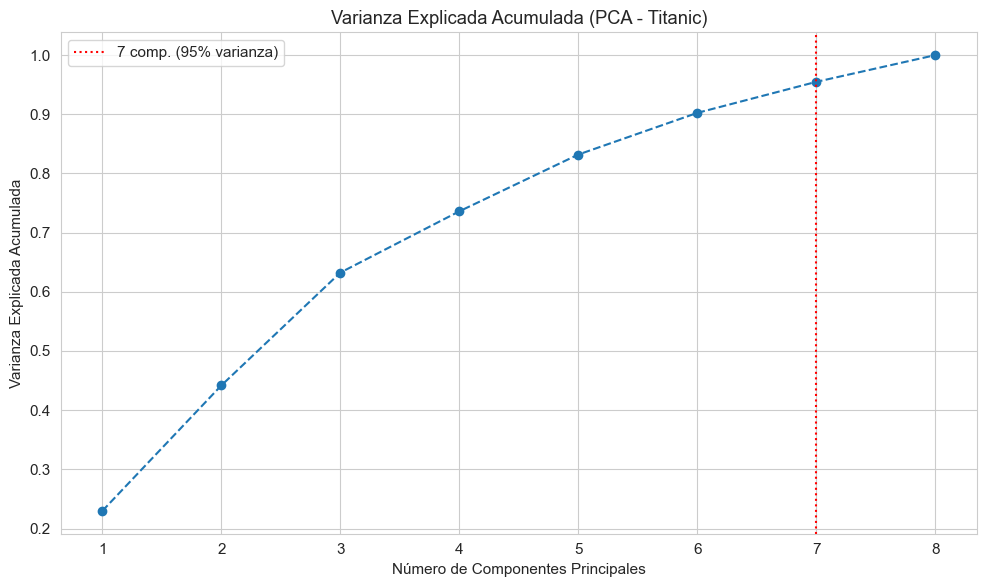

X_train_pca: (712, 7) | X_test_pca: (179, 7)


In [17]:
from sklearn.decomposition import PCA

pca = PCA(random_state=SEED)
pca.fit(X_train_std)
explained_cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = int(np.argmax(explained_cumsum >= 0.95) + 1)
print(f"Componentes para explicar el 95% de la varianza: {n_components_95} de {X_train_std.shape[1]}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_cumsum) + 1), explained_cumsum, marker='o', linestyle='--')
plt.axvline(x=n_components_95, color='r', linestyle=':', label=f'{n_components_95} comp. (95% varianza)')
plt.title('Varianza Explicada Acumulada (PCA - Titanic)')
plt.xlabel('Número de Componentes Principales'); plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "06_pca_explained_variance.png", dpi=120); plt.show()

# Transformación final con el número óptimo de componentes (95% de varianza)
pca_final = PCA(n_components=n_components_95, random_state=SEED)
X_train_pca = pca_final.fit_transform(X_train_std)
X_test_pca = pca_final.transform(X_test_std)
print(f"X_train_pca: {X_train_pca.shape} | X_test_pca: {X_test_pca.shape}")

## 17. Reducción de dimensiones — Algoritmo 2: LDA (Análisis Discriminante Lineal)

LDA es **supervisado**: maximiza la separación entre clases. En un problema binario produce a lo sumo
**1 componente**.

X_train_lda: (712, 1) | X_test_lda: (179, 1)


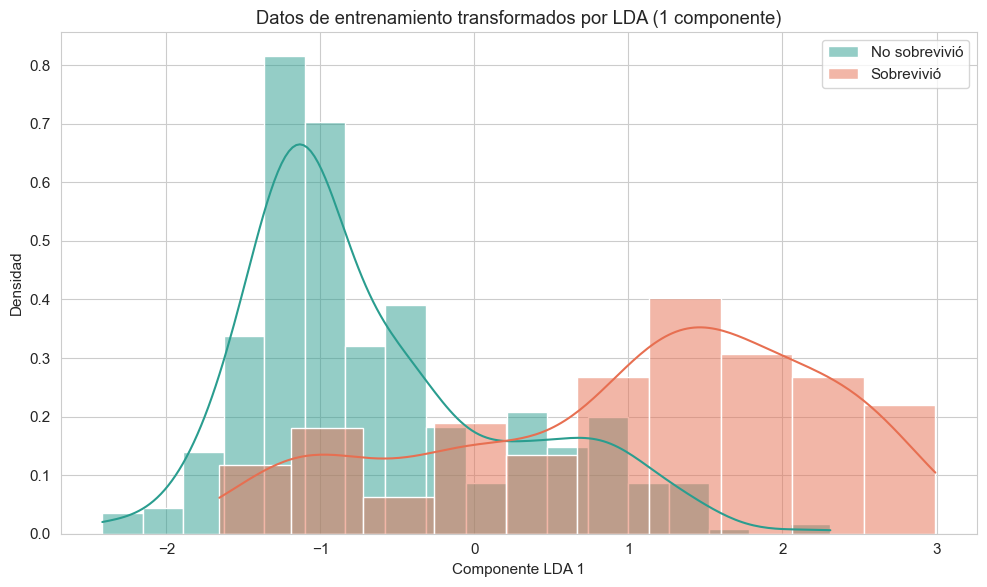

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_train_std, y_train)
X_train_lda = lda.transform(X_train_std)
X_test_lda = lda.transform(X_test_std)
print(f"X_train_lda: {X_train_lda.shape} | X_test_lda: {X_test_lda.shape}")

plt.figure(figsize=(10, 6))
for cls, color in [(0, COLOR_NEG), (1, COLOR_POS)]:
    sns.histplot(X_train_lda[y_train == cls].flatten(), color=color, label=LABELS[cls],
                 kde=True, stat='density', alpha=0.5)
plt.title('Datos de entrenamiento transformados por LDA (1 componente)')
plt.xlabel('Componente LDA 1'); plt.ylabel('Densidad'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig(OUT_DIR / "08_lda_visualization.png", dpi=120); plt.show()

## Modelo 1 — Regresión Logística

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Regresión Logística (Standard Features) ---


Mejores parámetros: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,Standard Features,0.77095,0.712121,0.681159,0.696296,0.834519


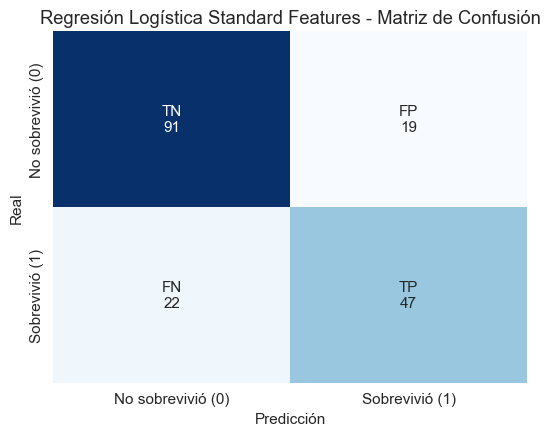

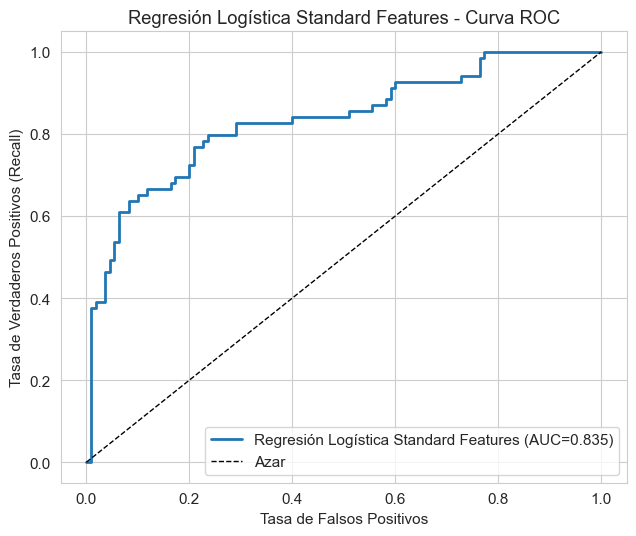

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/lr_std.joblib (0.001 MB)
--------------------------------------------------
--- Entrenando Regresión Logística (PCA Features) ---
Mejores parámetros: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,PCA Features,0.793296,0.75,0.695652,0.721805,0.832806


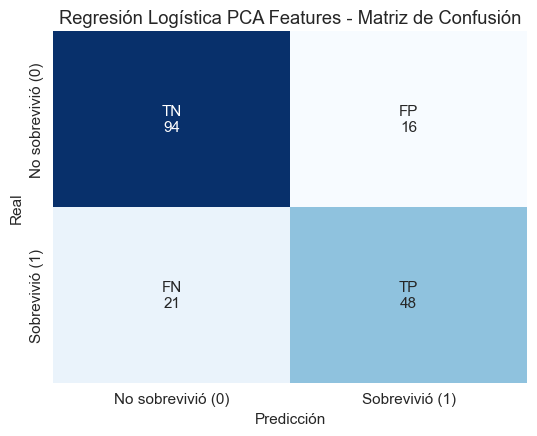

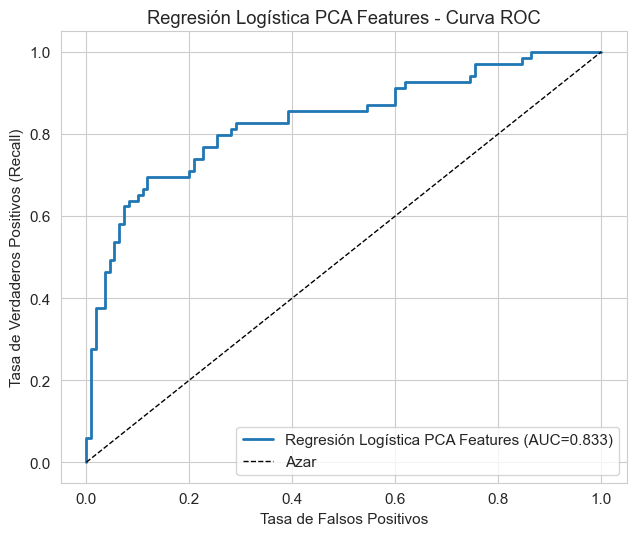

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/lr_pca.joblib (0.001 MB)
--------------------------------------------------
--- Entrenando Regresión Logística (LDA Features) ---
Mejores parámetros: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,LDA Features,0.793296,0.710526,0.782609,0.744828,0.838867


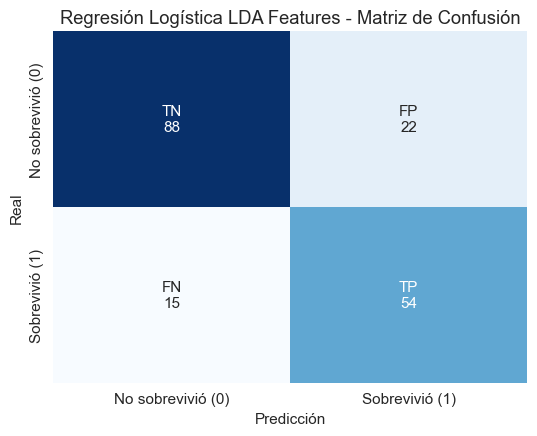

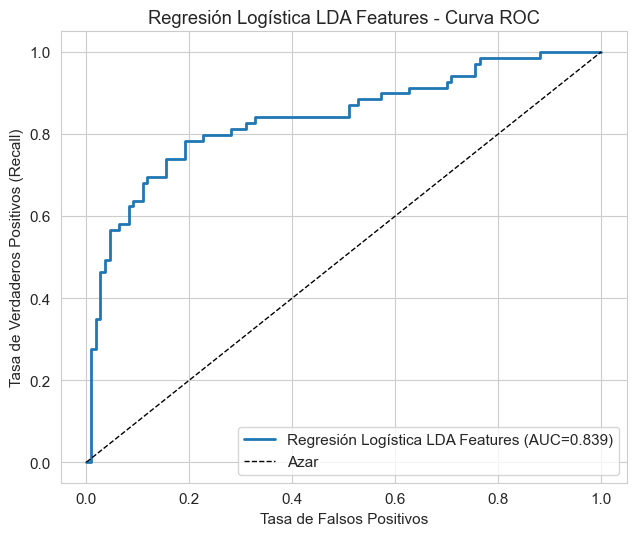

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/lr_lda.joblib (0.001 MB)
--------------------------------------------------


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [19]:
lr_params = {'penalty': ['l1','l2'], 'C': [0.01,0.1,1,10], 'solver': ['liblinear'], 'max_iter': [1000]}

# 1. LR sobre características originales (escaladas)
train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_std, y_train, X_test_std, y_test,
    "Regresión Logística", "Standard Features", "lr_std")

# 2. LR sobre características PCA
train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Regresión Logística", "PCA Features", "lr_pca")

# 3. LR sobre características LDA
train_and_evaluate_classifier(
    LogisticRegression(random_state=SEED), lr_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Regresión Logística", "LDA Features", "lr_lda")

## Modelo 2 — K-Nearest Neighbors (KNN)

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando K-Nearest Neighbors (KNN) (Standard Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,K-Nearest Neighbors (KNN),Standard Features,0.821229,0.793651,0.724638,0.757576,0.855468


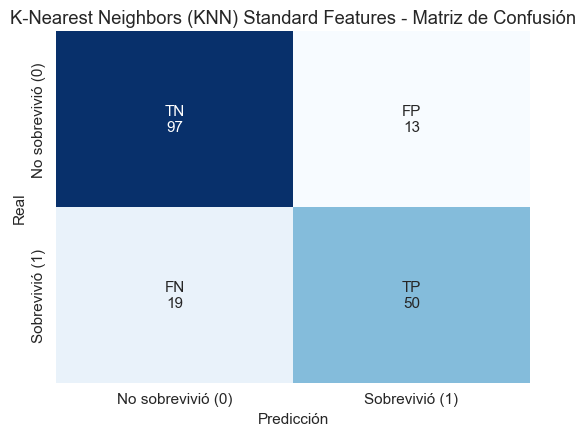

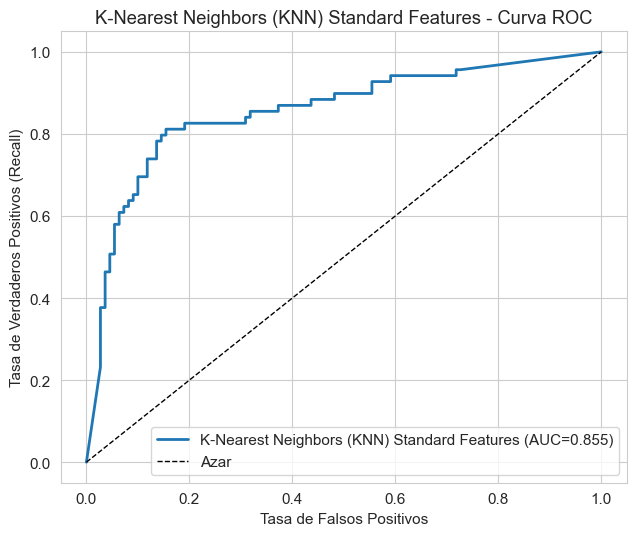

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/knn_std.joblib (0.104 MB)
--------------------------------------------------
--- Entrenando K-Nearest Neighbors (KNN) (PCA Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,K-Nearest Neighbors (KNN),PCA Features,0.815642,0.78125,0.724638,0.75188,0.854348


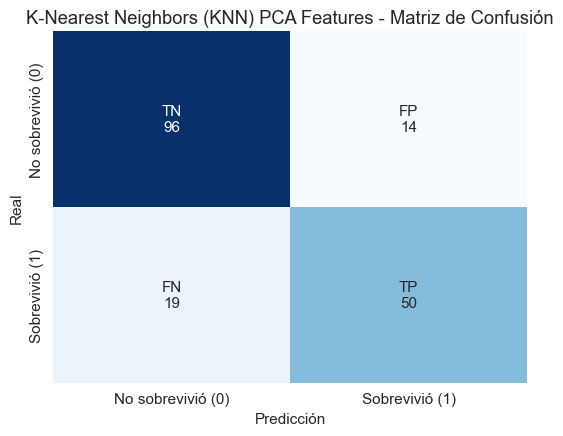

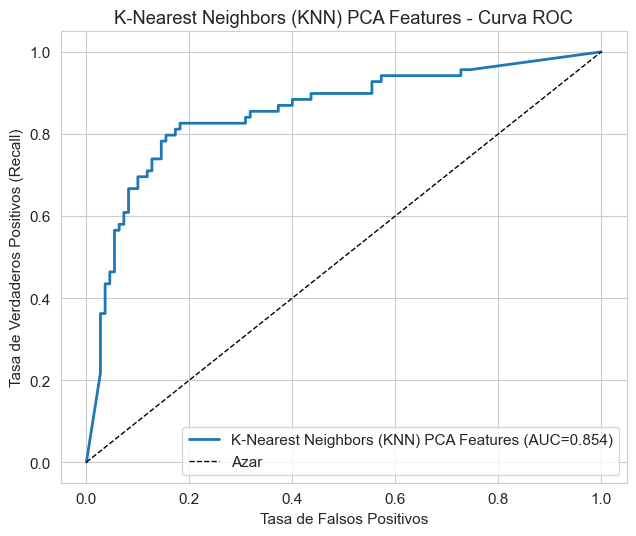

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/knn_pca.joblib (0.093 MB)
--------------------------------------------------
--- Entrenando K-Nearest Neighbors (KNN) (LDA Features) ---
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,K-Nearest Neighbors (KNN),LDA Features,0.810056,0.79661,0.681159,0.734375,0.795257


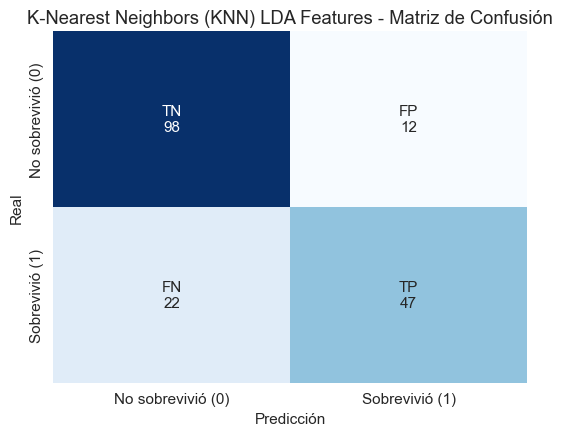

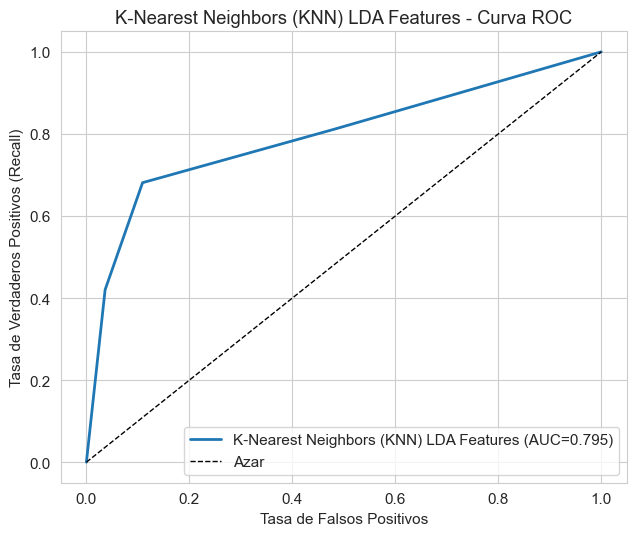

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/knn_lda.joblib (0.025 MB)
--------------------------------------------------


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
knn_params = {'n_neighbors': [3,5,7,9], 'weights': ['uniform','distance'], 'metric': ['euclidean','minkowski']}

# 1. KNN sobre características originales (escaladas)
train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_std, y_train, X_test_std, y_test,
    "K-Nearest Neighbors (KNN)", "Standard Features", "knn_std")

# 2. KNN sobre características PCA
train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "K-Nearest Neighbors (KNN)", "PCA Features", "knn_pca")

# 3. KNN sobre características LDA
train_and_evaluate_classifier(
    KNeighborsClassifier(), knn_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "K-Nearest Neighbors (KNN)", "LDA Features", "knn_lda")

## Modelo 3 — Naive Bayes Gaussiano

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Naive Bayes Gaussiano (Standard Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.0026826957952797246)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes Gaussiano,Standard Features,0.782123,0.727273,0.695652,0.711111,0.808169


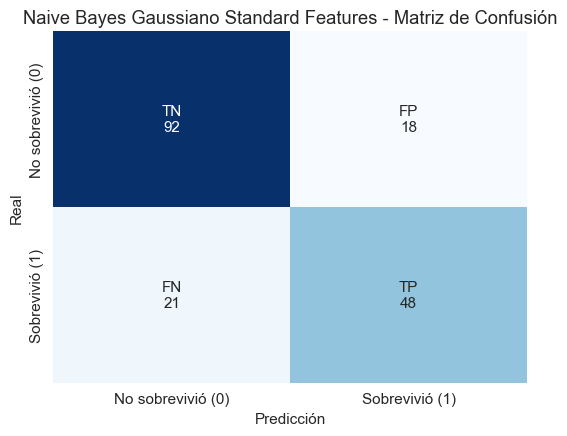

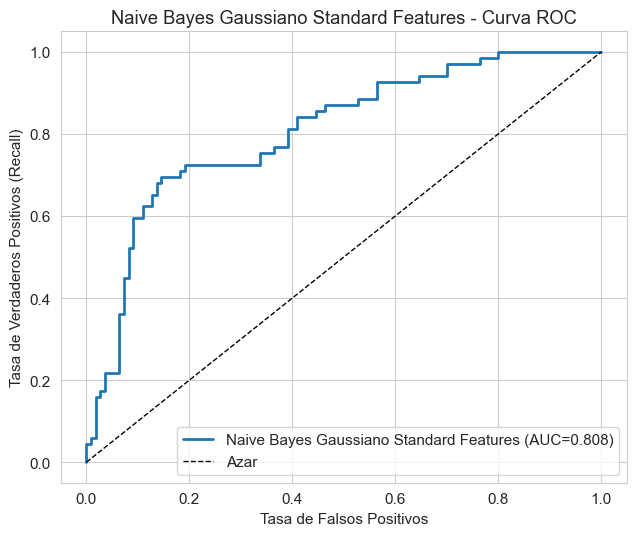

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/nb_std.joblib (0.001 MB)
--------------------------------------------------
--- Entrenando Naive Bayes Gaussiano (PCA Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.014563484775012436)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes Gaussiano,PCA Features,0.793296,0.775862,0.652174,0.708661,0.805534


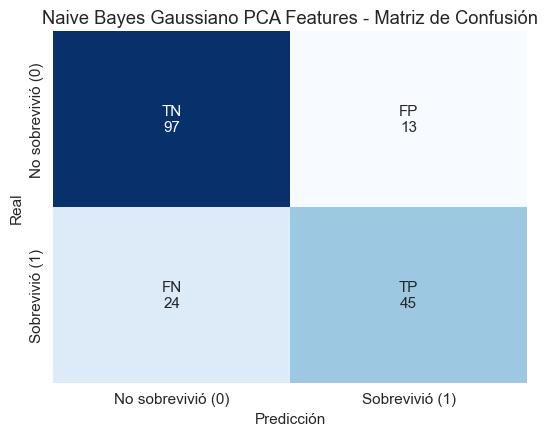

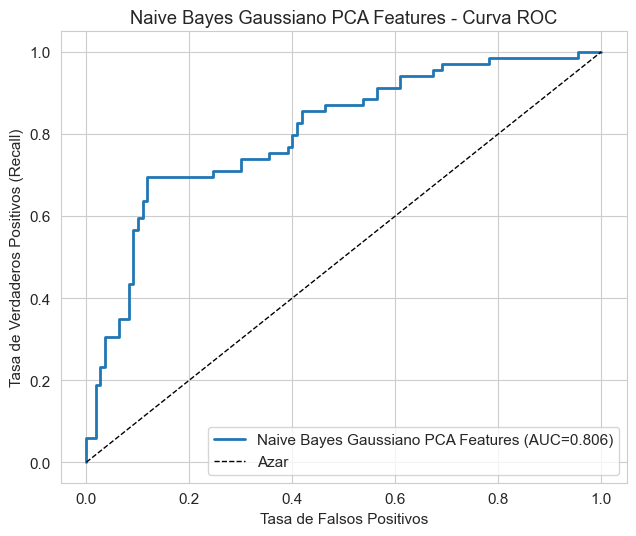

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/nb_pca.joblib (0.001 MB)
--------------------------------------------------
--- Entrenando Naive Bayes Gaussiano (LDA Features) ---
Mejores parámetros: {'var_smoothing': np.float64(0.0017575106248547913)}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes Gaussiano,LDA Features,0.804469,0.783333,0.681159,0.728682,0.838867


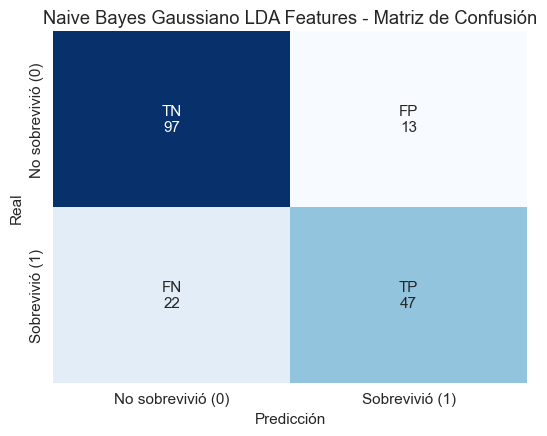

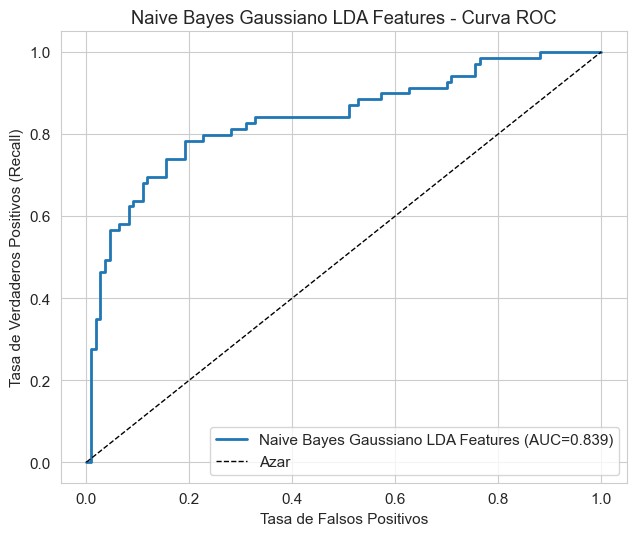

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/nb_lda.joblib (0.001 MB)
--------------------------------------------------


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",np.float64(0....5106248547913)


In [21]:
nb_params = {'var_smoothing': np.logspace(0, -9, num=50)}

# 1. NB sobre características originales (escaladas)
train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_std, y_train, X_test_std, y_test,
    "Naive Bayes Gaussiano", "Standard Features", "nb_std")

# 2. NB sobre características PCA
train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Naive Bayes Gaussiano", "PCA Features", "nb_pca")

# 3. NB sobre características LDA
train_and_evaluate_classifier(
    GaussianNB(), nb_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Naive Bayes Gaussiano", "LDA Features", "nb_lda")

## Modelo 4 — Árbol de Decisión

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Árbol de Decisión (Standard Features) ---


Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,Standard Features,0.798883,0.770492,0.681159,0.723077,0.776416


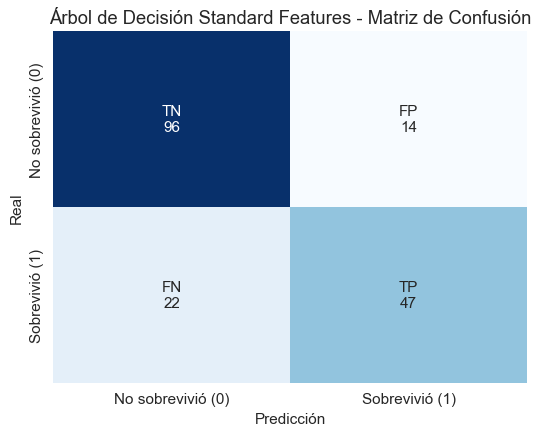

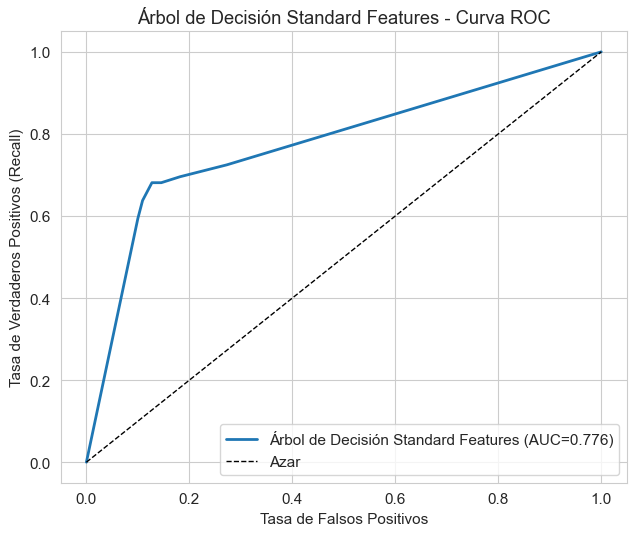

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/dt_std.joblib (0.020 MB)
--------------------------------------------------
--- Entrenando Árbol de Decisión (PCA Features) ---


Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,PCA Features,0.804469,0.757576,0.724638,0.740741,0.808893


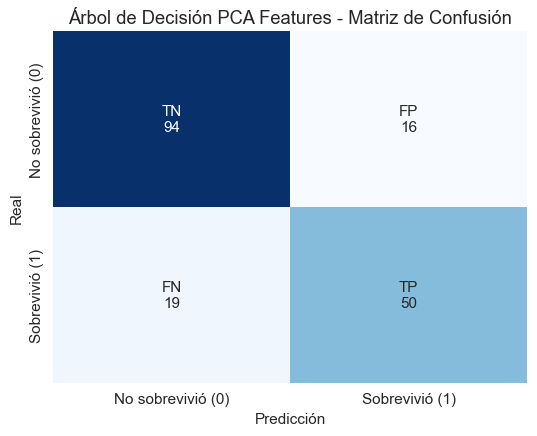

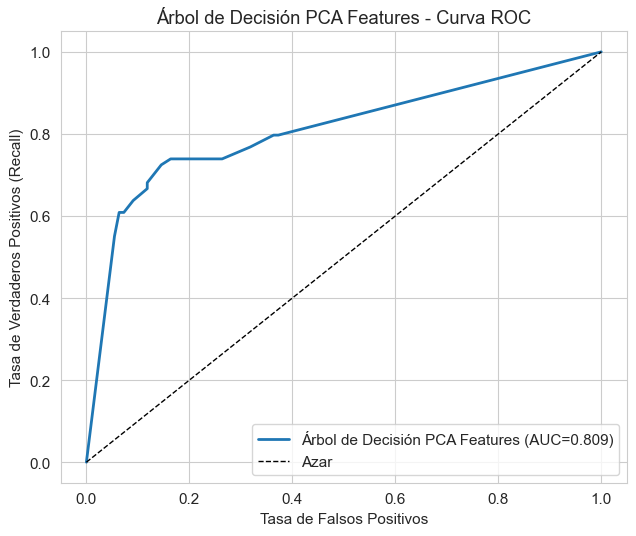

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/dt_pca.joblib (0.014 MB)
--------------------------------------------------
--- Entrenando Árbol de Decisión (LDA Features) ---


Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Árbol de Decisión,LDA Features,0.77095,0.75,0.608696,0.672,0.763702


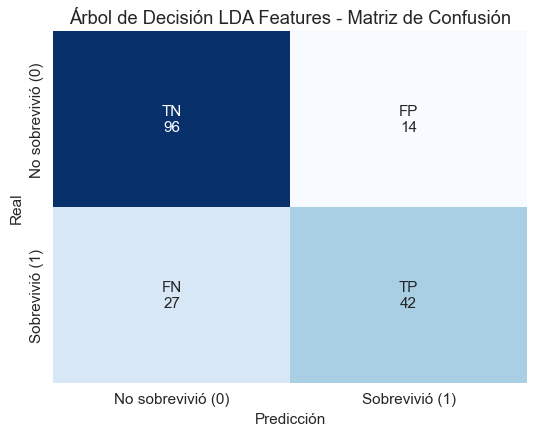

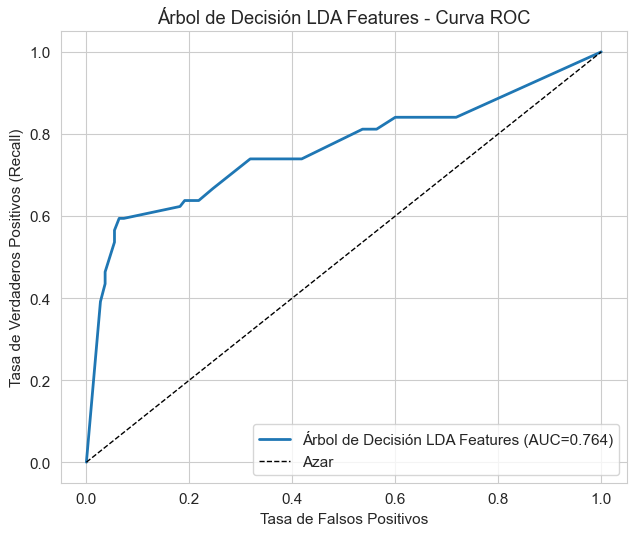

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/dt_lda.joblib (0.011 MB)
--------------------------------------------------


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [22]:
dt_params = {'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4], 'criterion': ['gini','entropy']}

# 1. DT sobre características originales (escaladas)
train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_std, y_train, X_test_std, y_test,
    "Árbol de Decisión", "Standard Features", "dt_std")

# 2. DT sobre características PCA
train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Árbol de Decisión", "PCA Features", "dt_pca")

# 3. DT sobre características LDA
train_and_evaluate_classifier(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Árbol de Decisión", "LDA Features", "dt_lda")

## Modelo 5 — Bosque Aleatorio (Random Forest)

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Bosque Aleatorio (Random Forest) (Standard Features) ---


Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Aleatorio (Random Forest),Standard Features,0.815642,0.78125,0.724638,0.75188,0.832411


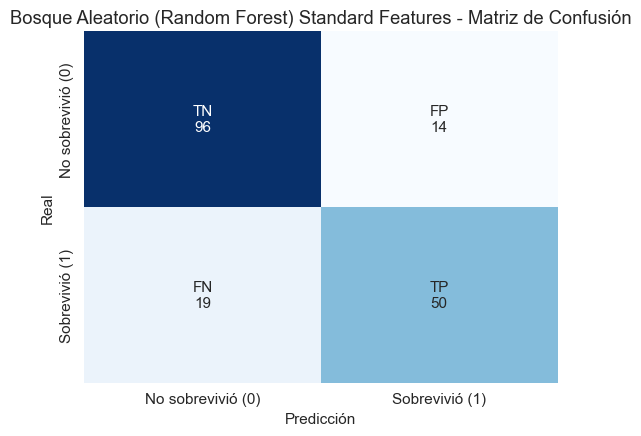

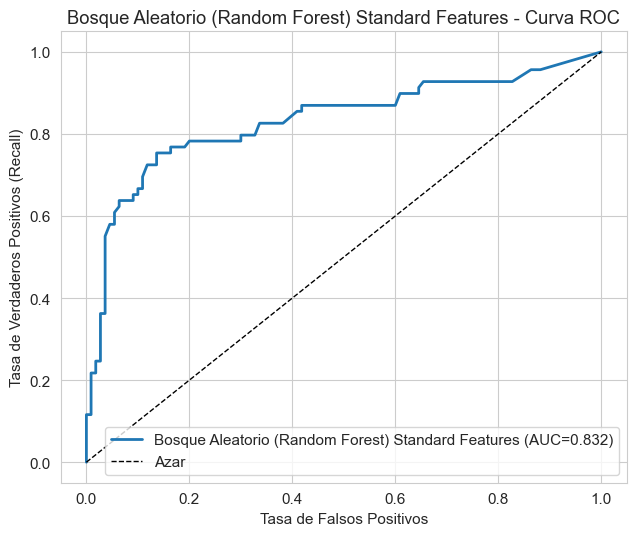

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/rf_std.joblib (2.252 MB)
--------------------------------------------------
--- Entrenando Bosque Aleatorio (Random Forest) (PCA Features) ---


Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Aleatorio (Random Forest),PCA Features,0.815642,0.790323,0.710145,0.748092,0.840316


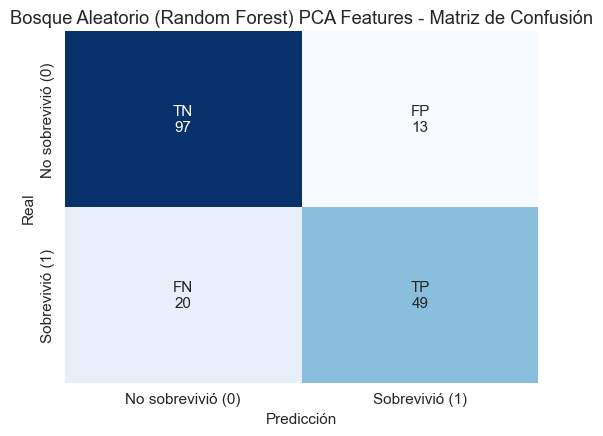

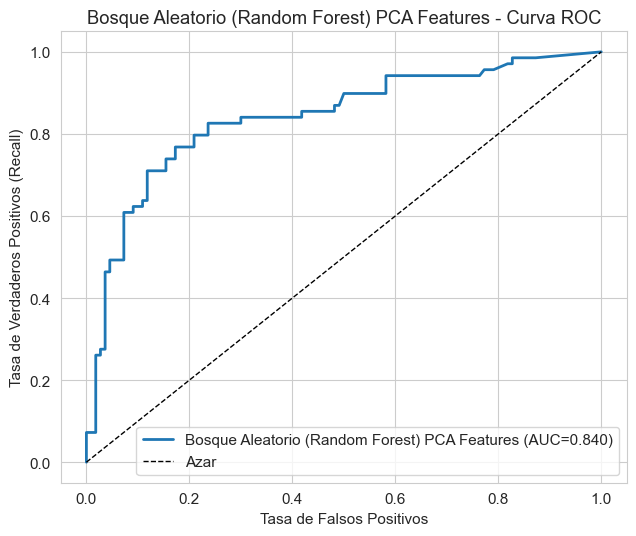

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/rf_pca.joblib (0.654 MB)
--------------------------------------------------
--- Entrenando Bosque Aleatorio (Random Forest) (LDA Features) ---


Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Bosque Aleatorio (Random Forest),LDA Features,0.787709,0.77193,0.637681,0.698413,0.797365


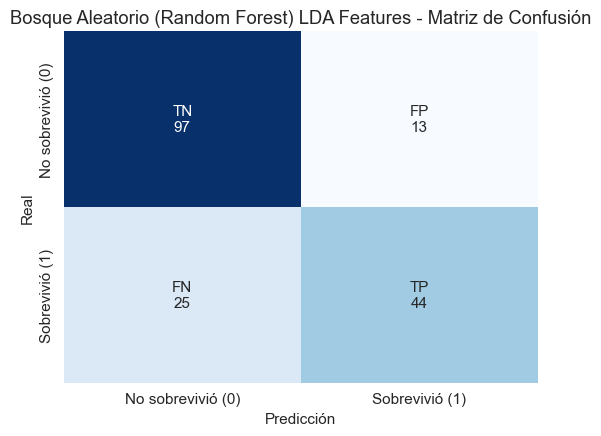

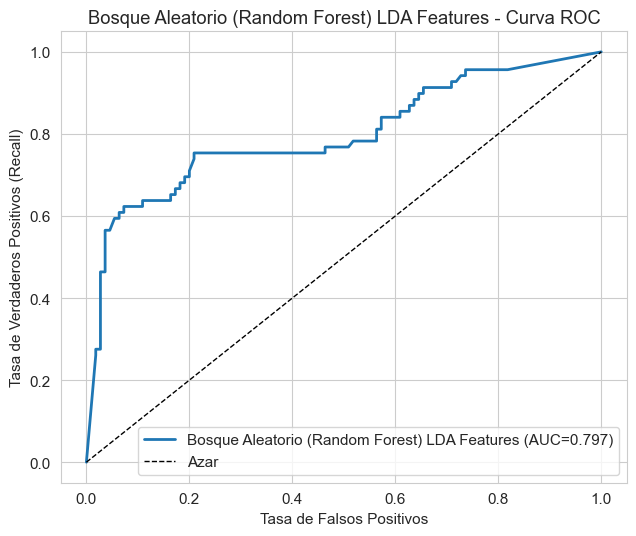

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/rf_lda.joblib (1.453 MB)
--------------------------------------------------


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [23]:
rf_params = {'n_estimators': [50,100,200], 'max_depth': [5,10,None], 'min_samples_split': [2,5], 'min_samples_leaf': [1,2], 'criterion': ['gini','entropy']}

# 1. RF sobre características originales (escaladas)
train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_std, y_train, X_test_std, y_test,
    "Bosque Aleatorio (Random Forest)", "Standard Features", "rf_std")

# 2. RF sobre características PCA
train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Bosque Aleatorio (Random Forest)", "PCA Features", "rf_pca")

# 3. RF sobre características LDA
train_and_evaluate_classifier(
    RandomForestClassifier(random_state=SEED), rf_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Bosque Aleatorio (Random Forest)", "LDA Features", "rf_lda")

## Modelo 6 — Máquina de Soporte Vectorial (SVM)

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Máquina de Soporte Vectorial (SVM) (Standard Features) ---


Mejores parámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Máquina de Soporte Vectorial (SVM),Standard Features,0.776536,0.737705,0.652174,0.692308,0.803294


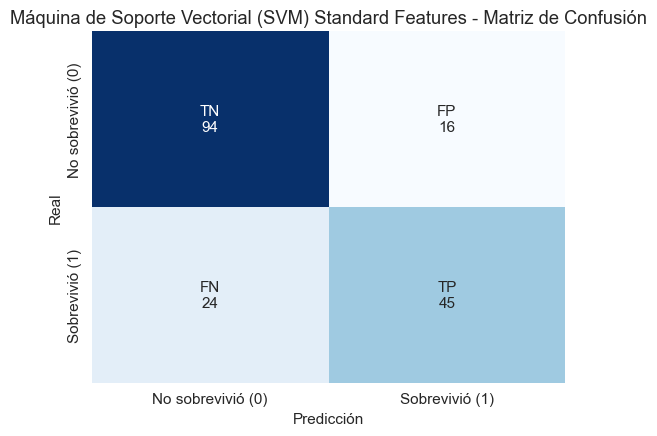

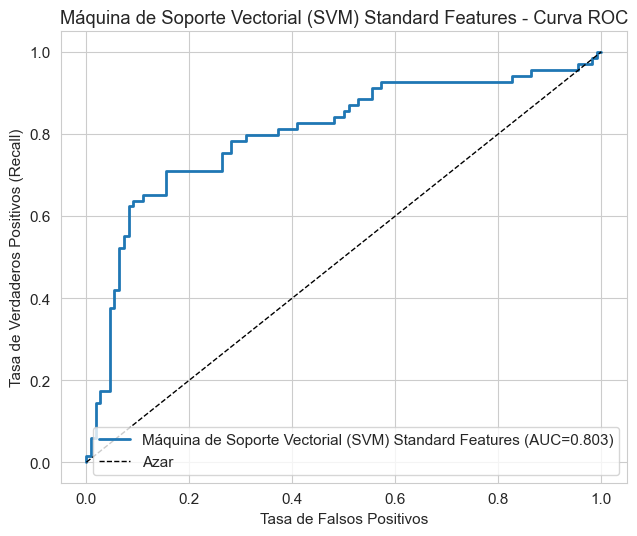

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/svm_std.joblib (0.027 MB)
--------------------------------------------------
--- Entrenando Máquina de Soporte Vectorial (SVM) (PCA Features) ---


Mejores parámetros: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Máquina de Soporte Vectorial (SVM),PCA Features,0.821229,0.824561,0.681159,0.746032,0.840184


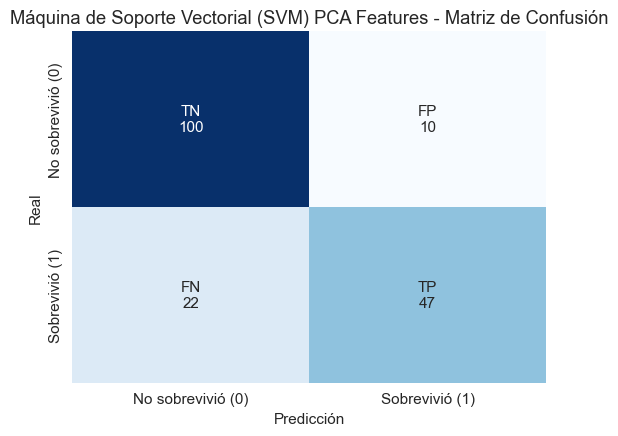

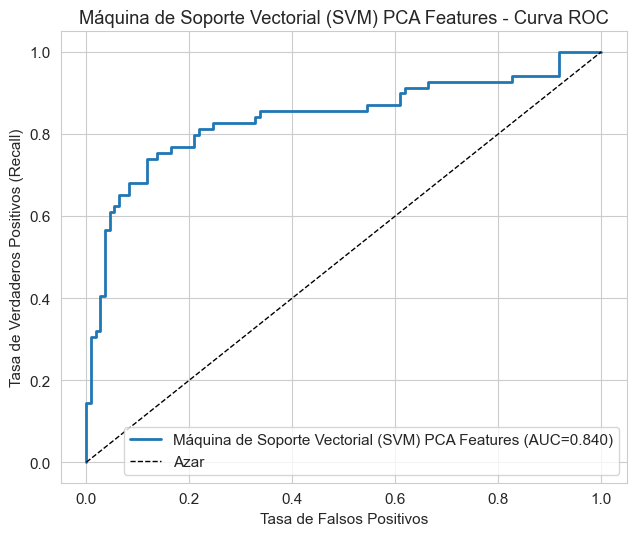

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/svm_pca.joblib (0.025 MB)
--------------------------------------------------
--- Entrenando Máquina de Soporte Vectorial (SVM) (LDA Features) ---
Mejores parámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Máquina de Soporte Vectorial (SVM),LDA Features,0.804469,0.774194,0.695652,0.732824,0.838867


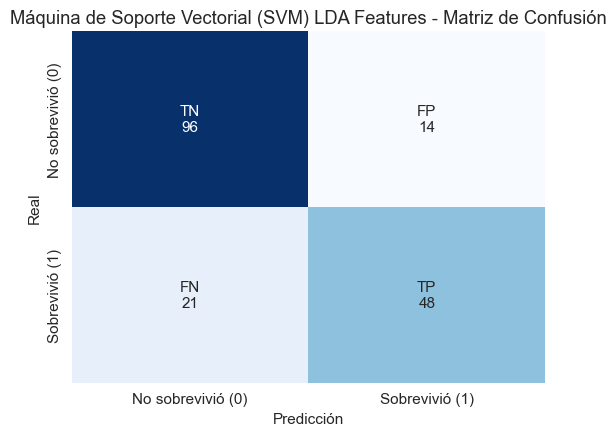

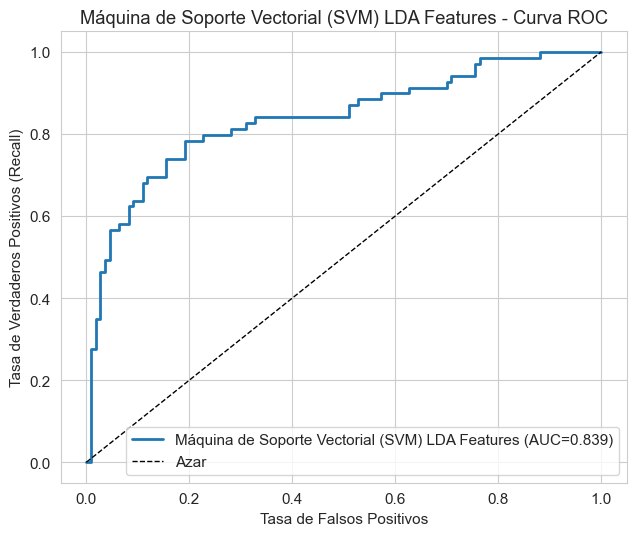

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/svm_lda.joblib (0.010 MB)
--------------------------------------------------


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
svm_params = {'C': [0.1,1,10], 'kernel': ['linear','rbf'], 'gamma': ['scale','auto']}

# 1. SVM sobre características originales (escaladas)
train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_std, y_train, X_test_std, y_test,
    "Máquina de Soporte Vectorial (SVM)", "Standard Features", "svm_std")

# 2. SVM sobre características PCA
train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Máquina de Soporte Vectorial (SVM)", "PCA Features", "svm_pca")

# 3. SVM sobre características LDA
train_and_evaluate_classifier(
    SVC(random_state=SEED, probability=True), svm_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Máquina de Soporte Vectorial (SVM)", "LDA Features", "svm_lda")

## Modelo 7 — Gradient Boosting

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Gradient Boosting (Standard Features) ---


Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,Standard Features,0.804469,0.774194,0.695652,0.732824,0.789065


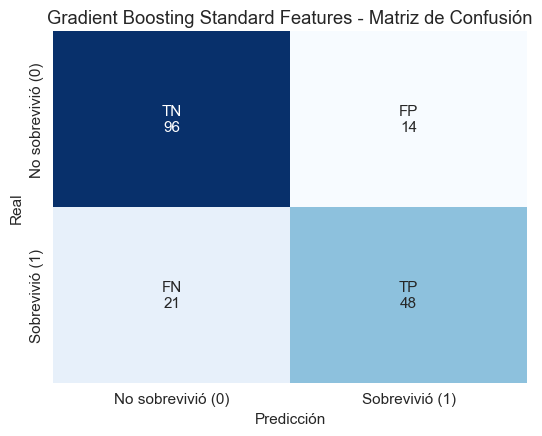

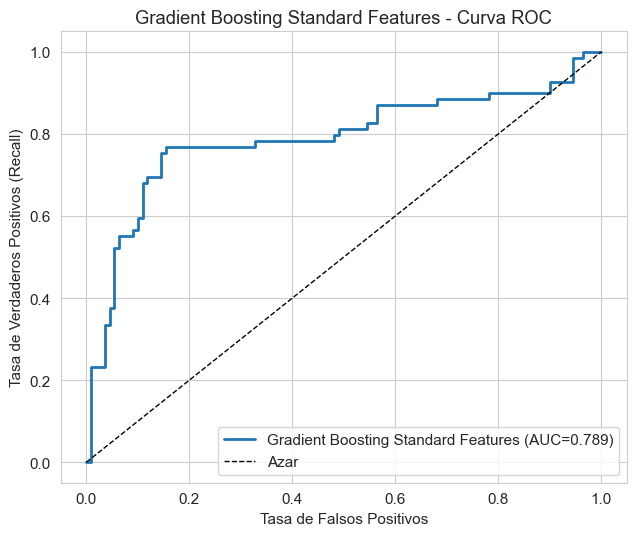

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/gb_std.joblib (0.248 MB)
--------------------------------------------------
--- Entrenando Gradient Boosting (PCA Features) ---


Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,PCA Features,0.810056,0.79661,0.681159,0.734375,0.822464


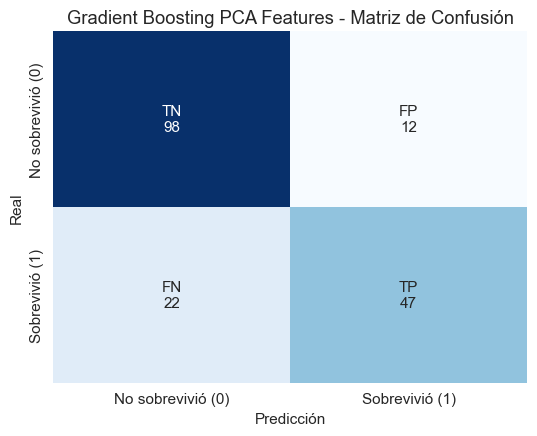

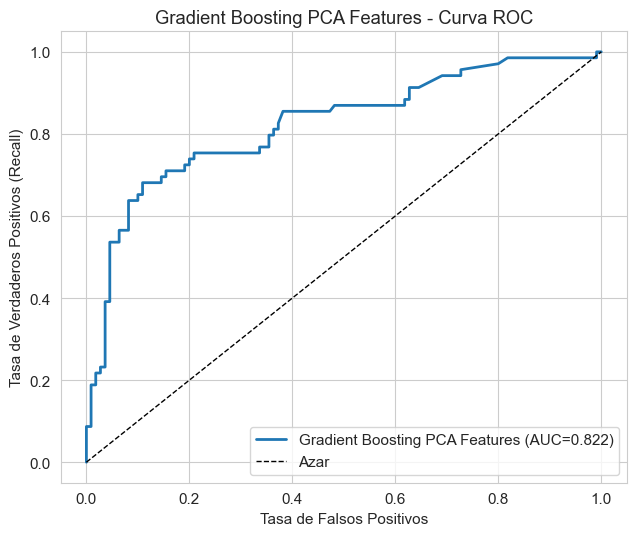

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/gb_pca.joblib (0.126 MB)
--------------------------------------------------
--- Entrenando Gradient Boosting (LDA Features) ---


Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Gradient Boosting,LDA Features,0.793296,0.775862,0.652174,0.708661,0.812648


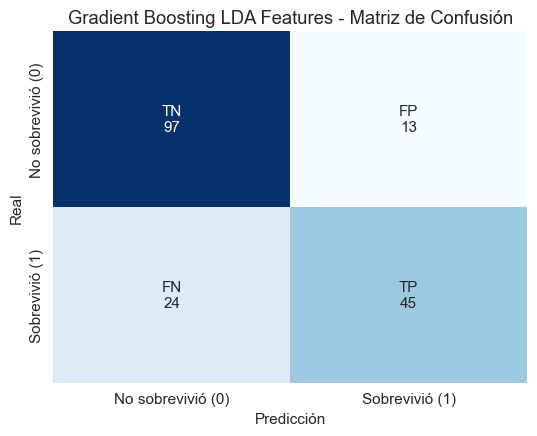

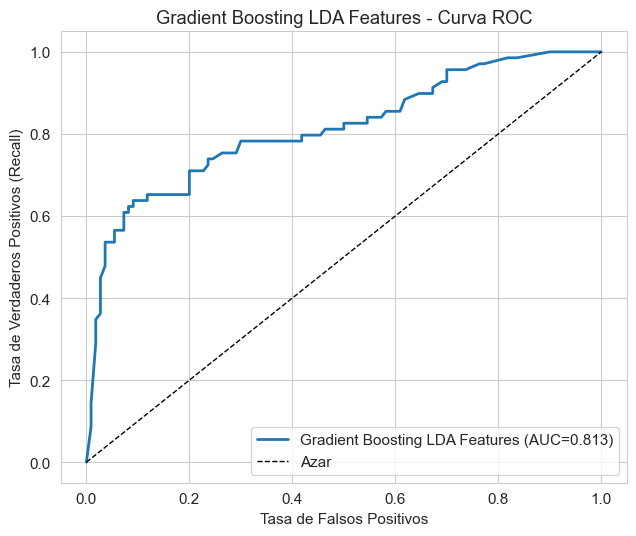

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/gb_lda.joblib (0.243 MB)
--------------------------------------------------


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [25]:
gb_params = {'n_estimators': [50,100,200], 'learning_rate': [0.01,0.1,0.2], 'max_depth': [3,5,7], 'subsample': [0.8,1.0]}

# 1. GB sobre características originales (escaladas)
train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_std, y_train, X_test_std, y_test,
    "Gradient Boosting", "Standard Features", "gb_std")

# 2. GB sobre características PCA
train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Gradient Boosting", "PCA Features", "gb_pca")

# 3. GB sobre características LDA
train_and_evaluate_classifier(
    GradientBoostingClassifier(random_state=SEED), gb_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Gradient Boosting", "LDA Features", "gb_lda")

## Modelo 8 — Red Neuronal (MLP)

Se entrena en sus tres versiones: características **originales (Standard)**, **PCA** y **LDA**, para
comparar el efecto de la reducción de dimensionalidad.

--- Entrenando Red Neuronal (MLP) (Standard Features) ---


Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal (MLP),Standard Features,0.832402,0.8,0.753623,0.776119,0.843742


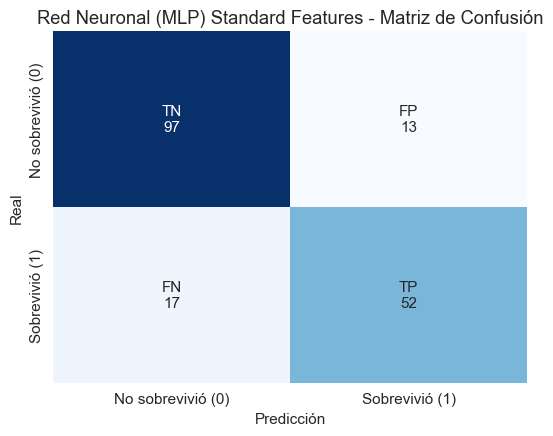

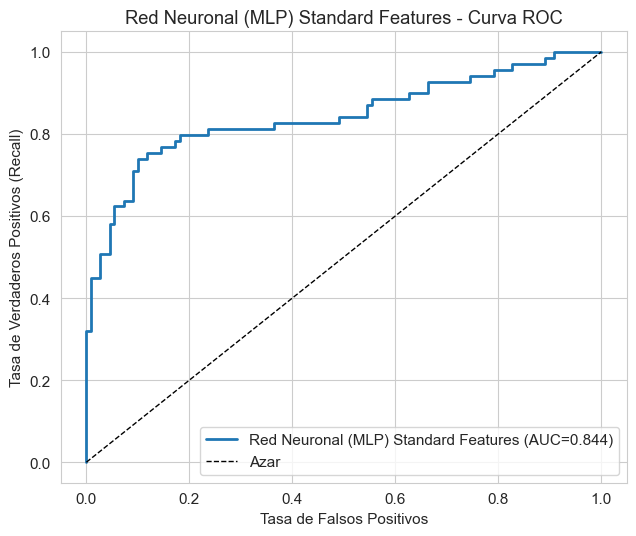

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/mlp_std.joblib (0.104 MB)
--------------------------------------------------
--- Entrenando Red Neuronal (MLP) (PCA Features) ---


Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal (MLP),PCA Features,0.793296,0.742424,0.710145,0.725926,0.812648


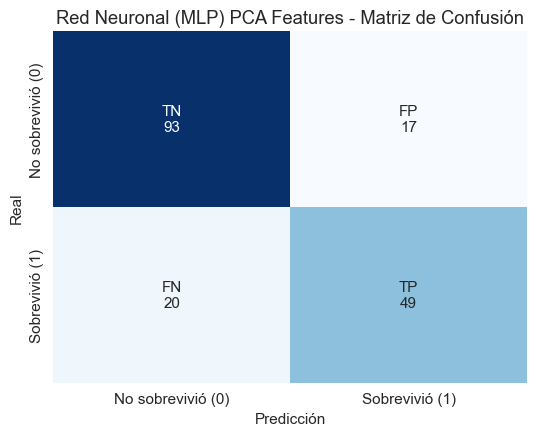

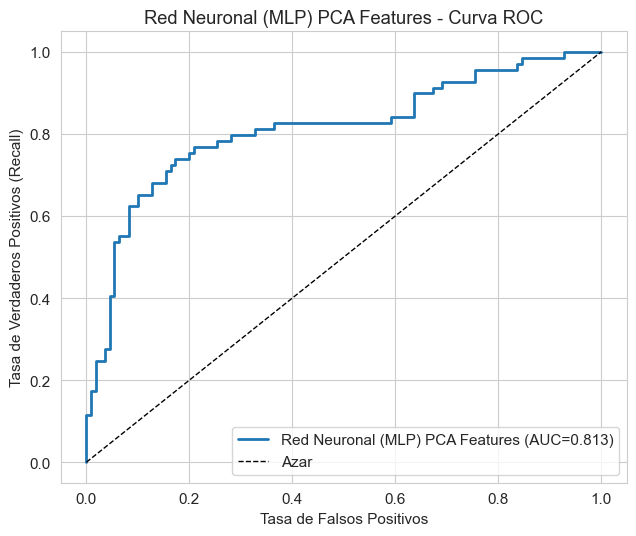

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/mlp_pca.joblib (0.102 MB)
--------------------------------------------------
--- Entrenando Red Neuronal (MLP) (LDA Features) ---


Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Métricas en Test:


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Red Neuronal (MLP),LDA Features,0.810056,0.786885,0.695652,0.738462,0.838867


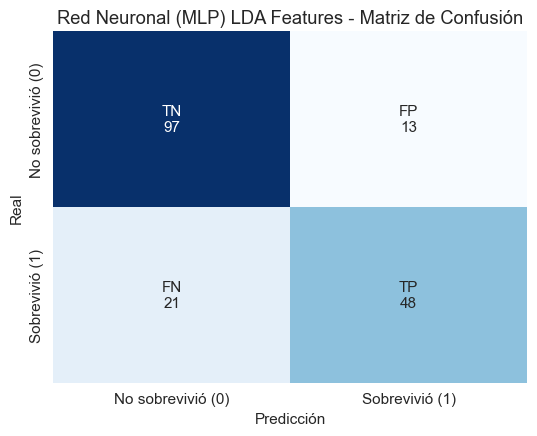

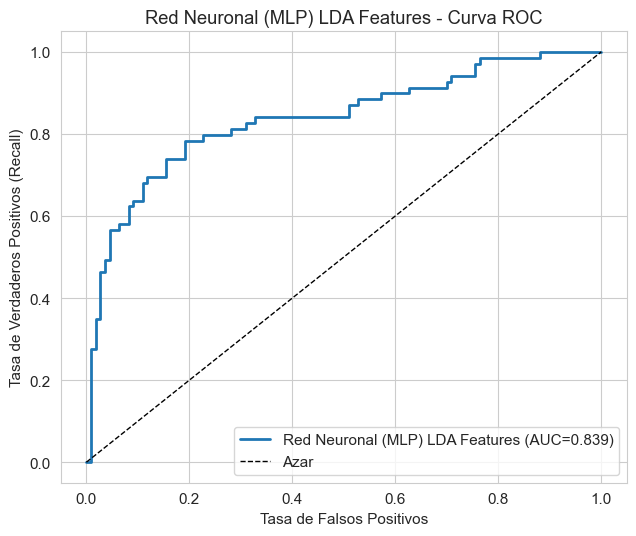

Modelo guardado en /home/jonathan/Documentos/MaestriaIA/AprendizajeAutomaticoEstadistico/models/mlp_lda.joblib (0.013 MB)
--------------------------------------------------


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [26]:
mlp_params = {'hidden_layer_sizes': [(50,),(100,),(50,50)], 'activation': ['relu','tanh'], 'solver': ['adam'], 'alpha': [0.0001,0.001], 'learning_rate_init': [0.001,0.01], 'max_iter': [500]}

# 1. MLP sobre características originales (escaladas)
train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_std, y_train, X_test_std, y_test,
    "Red Neuronal (MLP)", "Standard Features", "mlp_std")

# 2. MLP sobre características PCA
train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_pca, y_train, X_test_pca, y_test,
    "Red Neuronal (MLP)", "PCA Features", "mlp_pca")

# 3. MLP sobre características LDA
train_and_evaluate_classifier(
    MLPClassifier(random_state=SEED), mlp_params,
    X_train_lda, y_train, X_test_lda, y_test,
    "Red Neuronal (MLP)", "LDA Features", "mlp_lda")

## 18. Evaluación global de la clasificación (tabla comparativa)

Tabla consolidada de todos los modelos en sus tres versiones (Standard / PCA / LDA), con su tamaño en
disco.

In [27]:
all_results_df = pd.DataFrame(results)
all_results_df["Clave_Modelo"] = all_results_df["Modelo"] + "_" + all_results_df["Versión"]
all_results_df["Tamaño (MB)"] = all_results_df["Clave_Modelo"].map(model_sizes)
all_results_df = all_results_df.drop(columns=["Clave_Modelo"])

print("## Tabla Comparativa de Métricas y Tamaño de Modelos\n")
display(all_results_df.round(4))

# Mejor versión por métrica de interés (Recall)
print("\nTop-5 por Recall (clase positiva = sobrevivió):")
display(all_results_df.sort_values("Recall", ascending=False).head(5).round(4))

## Tabla Comparativa de Métricas y Tamaño de Modelos



,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC,Tamaño (MB)
0,Regresión Logística,Standard Features,0.7709,0.7121,0.6812,0.6963,0.8345,0.0009
1,Regresión Logística,PCA Features,0.7933,0.7500,0.6957,0.7218,0.8328,0.0009
2,Regresión Logística,LDA Features,0.7933,0.7105,0.7826,0.7448,0.8389,0.0008
3,K-Nearest Neighbors (KNN),Standard Features,0.8212,0.7937,0.7246,0.7576,0.8555,0.1039
4,K-Nearest Neighbors (KNN),PCA Features,0.8156,0.7812,0.7246,0.7519,0.8543,0.0926
5,K-Nearest Neighbors (KNN),LDA Features,0.8101,0.7966,0.6812,0.7344,0.7953,0.0245
6,Naive Bayes Gaussiano,Standard Features,0.7821,0.7273,0.6957,0.7111,0.8082,0.0010
7,Naive Bayes Gaussiano,PCA Features,0.7933,0.7759,0.6522,0.7087,0.8055,0.0010
8,Naive Bayes Gaussiano,LDA Features,0.8045,0.7833,0.6812,0.7287,0.8389,0.0008
9,Árbol de Decisión,Standard Features,0.7989,0.7705,0.6812,0.7231,0.7764,0.0203



Top-5 por Recall (clase positiva = sobrevivió):


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC,Tamaño (MB)
2,Regresión Logística,LDA Features,0.7933,0.7105,0.7826,0.7448,0.8389,0.0008
21,Red Neuronal (MLP),Standard Features,0.8324,0.8000,0.7536,0.7761,0.8437,0.1039
4,K-Nearest Neighbors (KNN),PCA Features,0.8156,0.7812,0.7246,0.7519,0.8543,0.0926
3,K-Nearest Neighbors (KNN),Standard Features,0.8212,0.7937,0.7246,0.7576,0.8555,0.1039
10,Árbol de Decisión,PCA Features,0.8045,0.7576,0.7246,0.7407,0.8089,0.0137


---
# Fase IV — Agrupamiento (no supervisado) con K-Means y GMM

Aplicamos **K-Means** y **GMM** sobre las tres representaciones (Standard, PCA, LDA) y con
`k = 2, 3 y 4`. Estos algoritmos **van "de cero"**: no usan la etiqueta `survived`. Los evaluamos con
las **métricas propias del agrupamiento**:

- **Inercia** (solo K-Means): suma de distancias intra-clúster (menor es mejor; siempre baja al subir k).
- **Coeficiente de Silueta:** cohesión vs. separación (rango [-1, 1]; mayor es mejor).
- **Calinski-Harabasz:** razón de dispersión entre/intra clústeres (mayor es mejor).
- **Davies-Bouldin:** similitud media entre clústeres (menor es mejor).

## 19. Algoritmo K-Means

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

kmeans_evaluation_results = []

def evaluate_kmeans_for_k_and_features(k_value, X_train_std, X_test_std, X_train_pca, X_test_pca,
                                       X_train_lda, X_test_lda, SEED):
    print(f"### K-Means con {k_value} clústeres ###\n")
    feature_sets = {
        "Standard Features": (X_train_std, X_test_std),
        "PCA Features": (X_train_pca, X_test_pca),
        "LDA Features": (X_train_lda, X_test_lda),
    }
    current_k_models = {}
    for feature_name, (Xtr, Xte) in feature_sets.items():
        print(f"--- K-Means ({feature_name}, k={k_value}) ---")
        km = KMeans(n_clusters=k_value, random_state=SEED, n_init=10)
        clusters_train = km.fit_predict(Xtr)
        clusters_test = km.predict(Xte)

        inertia = km.inertia_
        sil = silhouette_score(Xtr, clusters_train)
        ch = calinski_harabasz_score(Xtr, clusters_train)
        db = davies_bouldin_score(Xtr, clusters_train)

        print(f"- Inercia: {inertia:.2f}")
        print(f"- Silhouette: {sil:.4f}")
        print(f"- Calinski-Harabasz: {ch:.2f}")
        print(f"- Davies-Bouldin: {db:.4f}")
        print(f"Distribución train: {dict(pd.Series(clusters_train).value_counts())}")
        print("-" * 50)

        kmeans_evaluation_results.append({
            'k': k_value, 'Feature Set': feature_name, 'Inercia': inertia,
            'Silhouette Score': sil, 'Calinski-Harabasz Score': ch, 'Davies-Bouldin Score': db})
        current_k_models[feature_name.replace(' ', '_').lower()] = km
    return current_k_models

for k in (2, 3, 4):
    evaluate_kmeans_for_k_and_features(
        k, X_train_std, X_test_std, X_train_pca, X_test_pca, X_train_lda, X_test_lda, SEED)

kmeans_results_df = pd.DataFrame(kmeans_evaluation_results).sort_values(by=['k', 'Feature Set'])
print("\n### Tabla comparativa K-Means (k=2,3,4) ###")
display(kmeans_results_df.round(4))

### K-Means con 2 clústeres ###

--- K-Means (Standard Features, k=2) ---
- Inercia: 4747.09
- Silhouette: 0.2375
- Calinski-Harabasz: 141.92
- Davies-Bouldin: 1.7966
Distribución train: {0: np.int64(523), 1: np.int64(189)}
--------------------------------------------------
--- K-Means (PCA Features, k=2) ---
- Inercia: 4507.35
- Silhouette: 0.2375
- Calinski-Harabasz: 146.74
- Davies-Bouldin: 1.7515
Distribución train: {1: np.int64(524), 0: np.int64(188)}
--------------------------------------------------
--- K-Means (LDA Features, k=2) ---
- Inercia: 257.62
- Silhouette: 0.6832
- Calinski-Harabasz: 2578.57
- Davies-Bouldin: 0.4299
Distribución train: {0: np.int64(422), 1: np.int64(290)}
--------------------------------------------------
### K-Means con 3 clústeres ###

--- K-Means (Standard Features, k=3) ---


- Inercia: 3858.76
- Silhouette: 0.2982
- Calinski-Harabasz: 168.78
- Davies-Bouldin: 1.4113
Distribución train: {1: np.int64(465), 0: np.int64(192), 2: np.int64(55)}
--------------------------------------------------
--- K-Means (PCA Features, k=3) ---


- Inercia: 3625.12
- Silhouette: 0.3179
- Calinski-Harabasz: 177.37
- Davies-Bouldin: 1.3201
Distribución train: {1: np.int64(499), 2: np.int64(158), 0: np.int64(55)}
--------------------------------------------------
--- K-Means (LDA Features, k=3) ---


- Inercia: 132.09
- Silhouette: 0.6110
- Calinski-Harabasz: 2847.84
- Davies-Bouldin: 0.5374
Distribución train: {0: np.int64(362), 2: np.int64(182), 1: np.int64(168)}
--------------------------------------------------
### K-Means con 4 clústeres ###

--- K-Means (Standard Features, k=4) ---
- Inercia: 3148.18
- Silhouette: 0.3327
- Calinski-Harabasz: 190.99
- Davies-Bouldin: 1.2696
Distribución train: {0: np.int64(395), 1: np.int64(156), 3: np.int64(106), 2: np.int64(55)}
--------------------------------------------------
--- K-Means (PCA Features, k=4) ---
- Inercia: 2911.41
- Silhouette: 0.3525
- Calinski-Harabasz: 204.88
- Davies-Bouldin: 1.2415
Distribución train: {1: np.int64(413), 2: np.int64(137), 3: np.int64(107), 0: np.int64(55)}
--------------------------------------------------
--- K-Means (LDA Features, k=4) ---
- Inercia: 71.62
- Silhouette: 0.6107
- Calinski-Harabasz: 3695.92
- Davies-Bouldin: 0.4869
Distribución train: {0: np.int64(305), 2: np.int64(163), 3: np.int64(15

,k,Feature Set,Inercia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,257.6209,0.6832,2578.5710,0.4299
1,2,PCA Features,4507.3531,0.2375,146.7432,1.7515
0,2,Standard Features,4747.0934,0.2375,141.9234,1.7966
5,3,LDA Features,132.0925,0.6110,2847.8428,0.5374
4,3,PCA Features,3625.1241,0.3179,177.3721,1.3201
3,3,Standard Features,3858.7636,0.2982,168.7847,1.4113
8,4,LDA Features,71.6205,0.6107,3695.9181,0.4869
7,4,PCA Features,2911.4080,0.3525,204.8824,1.2415
6,4,Standard Features,3148.1842,0.3327,190.9941,1.2696


## 20. Algoritmo GMM (Gaussian Mixture Model)

GMM es **probabilístico**: en lugar de asignar cada punto a un único clúster por distancia, modela los
datos como una mezcla de gaussianas y entrega **probabilidades de pertenencia**. Suele superar a K-Means
cuando los grupos **no son esféricos**, como ocurre en datasets más complejos (caso del Titanic).

In [29]:
from sklearn.mixture import GaussianMixture

gmm_evaluation_results = []

def evaluate_gmm_for_k_and_features(k_value, X_train_std, X_test_std, X_train_pca, X_test_pca,
                                    X_train_lda, X_test_lda, SEED):
    print(f"### GMM con {k_value} componentes ###\n")
    feature_sets = {
        "Standard Features": (X_train_std, X_test_std),
        "PCA Features": (X_train_pca, X_test_pca),
        "LDA Features": (X_train_lda, X_test_lda),
    }
    current_k_models = {}
    for feature_name, (Xtr, Xte) in feature_sets.items():
        print(f"--- GMM ({feature_name}, k={k_value}) ---")
        gmm = GaussianMixture(n_components=k_value, random_state=SEED, n_init=10, max_iter=300)
        gmm.fit(Xtr)
        clusters_train = gmm.predict(Xtr)
        clusters_test = gmm.predict(Xte)

        log_likelihood = gmm.score(Xtr)   # GMM no tiene inercia; usamos log-verosimilitud
        sil = silhouette_score(Xtr, clusters_train)
        ch = calinski_harabasz_score(Xtr, clusters_train)
        db = davies_bouldin_score(Xtr, clusters_train)

        print(f"- Log-verosimilitud: {log_likelihood:.2f}")
        print(f"- Silhouette: {sil:.4f}")
        print(f"- Calinski-Harabasz: {ch:.2f}")
        print(f"- Davies-Bouldin: {db:.4f}")
        print(f"Distribución train: {dict(pd.Series(clusters_train).value_counts())}")
        print("-" * 50)

        gmm_evaluation_results.append({
            'k': k_value, 'Feature Set': feature_name, 'Log Likelihood': log_likelihood,
            'Silhouette Score': sil, 'Calinski-Harabasz Score': ch, 'Davies-Bouldin Score': db})
        current_k_models[feature_name.replace(' ', '_').lower()] = gmm
    return current_k_models

for k in (2, 3, 4):
    evaluate_gmm_for_k_and_features(
        k, X_train_std, X_test_std, X_train_pca, X_test_pca, X_train_lda, X_test_lda, SEED)

gmm_results_df = pd.DataFrame(gmm_evaluation_results).sort_values(by=['k', 'Feature Set'])
print("\n### Tabla comparativa GMM (k=2,3,4) ###")
display(gmm_results_df.round(4))

### GMM con 2 componentes ###

--- GMM (Standard Features, k=2) ---


- Log-verosimilitud: 1.52
- Silhouette: 0.2783
- Calinski-Harabasz: 138.29
- Davies-Bouldin: 1.9520
Distribución train: {1: np.int64(518), 0: np.int64(194)}
--------------------------------------------------
--- GMM (PCA Features, k=2) ---


- Log-verosimilitud: -2.60
- Silhouette: 0.2902
- Calinski-Harabasz: 146.12
- Davies-Bouldin: 1.8951
Distribución train: {1: np.int64(518), 0: np.int64(194)}
--------------------------------------------------
--- GMM (LDA Features, k=2) ---
- Log-verosimilitud: -1.50
- Silhouette: 0.6640
- Calinski-Harabasz: 2316.42
- Davies-Bouldin: 0.4405
Distribución train: {0: np.int64(391), 1: np.int64(321)}
--------------------------------------------------
### GMM con 3 componentes ###

--- GMM (Standard Features, k=3) ---


- Log-verosimilitud: 3.25
- Silhouette: 0.2785
- Calinski-Harabasz: 150.71
- Davies-Bouldin: 1.5541
Distribución train: {2: np.int64(422), 1: np.int64(170), 0: np.int64(120)}
--------------------------------------------------
--- GMM (PCA Features, k=3) ---


- Log-verosimilitud: -2.00
- Silhouette: 0.3069
- Calinski-Harabasz: 145.11
- Davies-Bouldin: 1.4381
Distribución train: {2: np.int64(501), 0: np.int64(107), 1: np.int64(104)}
--------------------------------------------------
--- GMM (LDA Features, k=3) ---
- Log-verosimilitud: -1.49
- Silhouette: 0.5879
- Calinski-Harabasz: 2632.42
- Davies-Bouldin: 0.5226
Distribución train: {0: np.int64(337), 1: np.int64(223), 2: np.int64(152)}
--------------------------------------------------
### GMM con 4 componentes ###

--- GMM (Standard Features, k=4) ---


- Log-verosimilitud: 4.56
- Silhouette: 0.2458
- Calinski-Harabasz: 140.56
- Davies-Bouldin: 1.3767
Distribución train: {1: np.int64(422), 3: np.int64(170), 0: np.int64(65), 2: np.int64(55)}
--------------------------------------------------
--- GMM (PCA Features, k=4) ---


- Log-verosimilitud: 1.50
- Silhouette: 0.2048
- Calinski-Harabasz: 96.23
- Davies-Bouldin: 2.2814
Distribución train: {0: np.int64(359), 2: np.int64(155), 3: np.int64(127), 1: np.int64(71)}
--------------------------------------------------
--- GMM (LDA Features, k=4) ---
- Log-verosimilitud: -1.47
- Silhouette: 0.6076
- Calinski-Harabasz: 3592.95
- Davies-Bouldin: 0.4704
Distribución train: {0: np.int64(318), 1: np.int64(174), 2: np.int64(138), 3: np.int64(82)}
--------------------------------------------------

### Tabla comparativa GMM (k=2,3,4) ###


,k,Feature Set,Log Likelihood,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,-1.4966,0.6640,2316.4194,0.4405
1,2,PCA Features,-2.5957,0.2902,146.1184,1.8951
0,2,Standard Features,1.5221,0.2783,138.2950,1.9520
5,3,LDA Features,-1.4872,0.5879,2632.4155,0.5226
4,3,PCA Features,-2.0046,0.3069,145.1146,1.4381
3,3,Standard Features,3.2541,0.2785,150.7102,1.5541
8,4,LDA Features,-1.4704,0.6076,3592.9521,0.4704
7,4,PCA Features,1.4979,0.2048,96.2273,2.2814
6,4,Standard Features,4.5567,0.2458,140.5618,1.3767


## 21. Comparación de rendimiento entre K-Means y GMM

In [30]:
print("### Resultados K-Means ###")
display(kmeans_results_df.round(4))
print("\n### Resultados GMM ###")
display(gmm_results_df.round(4))

### Resultados K-Means ###


,k,Feature Set,Inercia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,257.6209,0.6832,2578.5710,0.4299
1,2,PCA Features,4507.3531,0.2375,146.7432,1.7515
0,2,Standard Features,4747.0934,0.2375,141.9234,1.7966
5,3,LDA Features,132.0925,0.6110,2847.8428,0.5374
4,3,PCA Features,3625.1241,0.3179,177.3721,1.3201
3,3,Standard Features,3858.7636,0.2982,168.7847,1.4113
8,4,LDA Features,71.6205,0.6107,3695.9181,0.4869
7,4,PCA Features,2911.4080,0.3525,204.8824,1.2415
6,4,Standard Features,3148.1842,0.3327,190.9941,1.2696



### Resultados GMM ###


,k,Feature Set,Log Likelihood,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,2,LDA Features,-1.4966,0.6640,2316.4194,0.4405
1,2,PCA Features,-2.5957,0.2902,146.1184,1.8951
0,2,Standard Features,1.5221,0.2783,138.2950,1.9520
5,3,LDA Features,-1.4872,0.5879,2632.4155,0.5226
4,3,PCA Features,-2.0046,0.3069,145.1146,1.4381
3,3,Standard Features,3.2541,0.2785,150.7102,1.5541
8,4,LDA Features,-1.4704,0.6076,3592.9521,0.4704
7,4,PCA Features,1.4979,0.2048,96.2273,2.2814
6,4,Standard Features,4.5567,0.2458,140.5618,1.3767


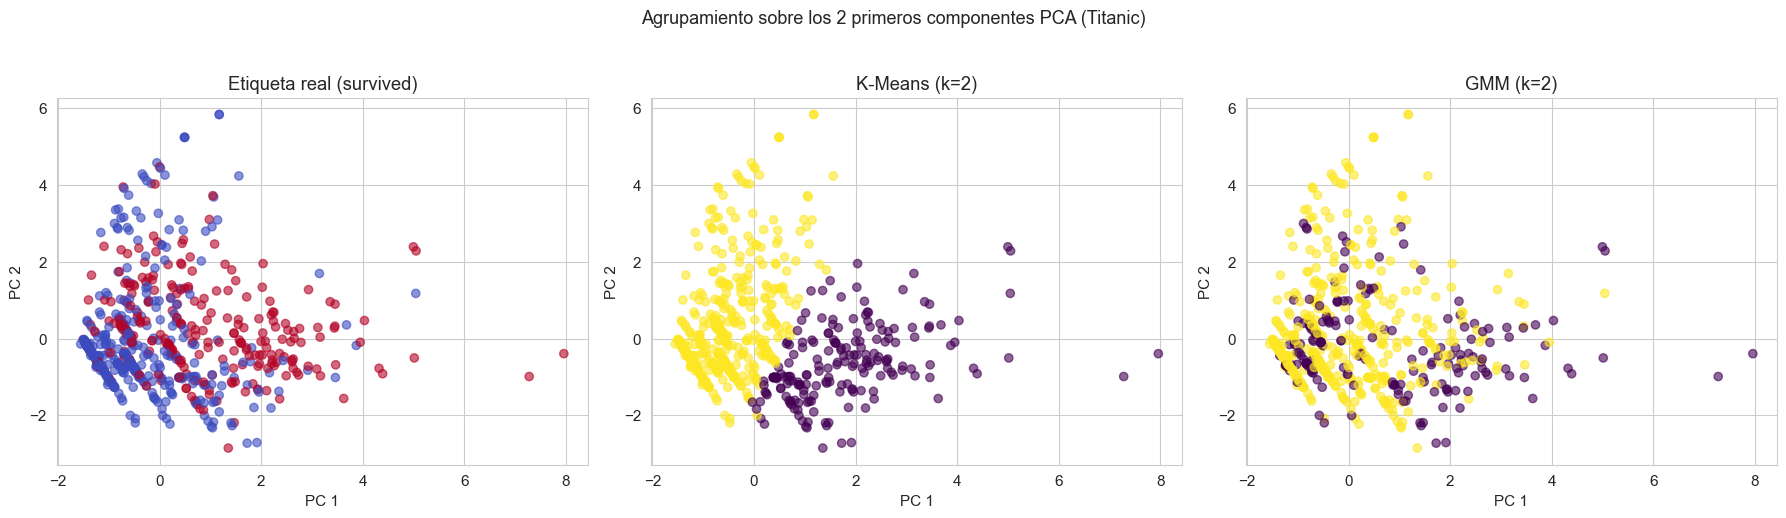

In [31]:
# Visualización de los clústeres en el plano de los 2 primeros componentes PCA (k=2)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

km2 = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(X_train_pca)
gmm2 = GaussianMixture(n_components=2, random_state=SEED, n_init=10).fit(X_train_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
axes[0].set_title("Etiqueta real (survived)")
axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=km2.labels_, cmap="viridis", alpha=0.6)
axes[1].set_title("K-Means (k=2)")
axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=gmm2.predict(X_train_pca), cmap="viridis", alpha=0.6)
axes[2].set_title("GMM (k=2)")
for ax in axes:
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
fig.suptitle("Agrupamiento sobre los 2 primeros componentes PCA (Titanic)", y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "09_clusters_pca.png", dpi=120); plt.show()

## 22. Conclusiones

*(Resultados de esta ejecución; pueden variar mínimamente entre corridas.)*

**Clasificación — efecto de PCA y LDA (métrica de evaluación: métricas básicas — Accuracy, Precision, Recall, F1 y AUC):**
- Las métricas globales del Titanic (**~0.77–0.83 de accuracy**) son **claramente más bajas** que en el dataset de cáncer de mama (>0.95), confirmando que es un problema **más complejo y menos separable**, tal como anticipó el profesor.
- **Mejor accuracy:** Red Neuronal (MLP) sobre características originales = **0.832**. **Mejor Recall** (clase positiva = sobrevivió): Regresión Logística con **LDA** = **0.783**.
- **La reducción de dimensiones mantiene (e incluso mejora levemente) las métricas:** se pasa de **8 variables** a **7 componentes con PCA** (95 % de varianza) o a **1 sola dimensión con LDA**, sin pérdida relevante. Ej.: SVM sube de 0.776 a **0.821** de accuracy con PCA; Regresión Logística sube de 0.771 a **0.793** con PCA/LDA. → **Se cumple el objetivo de la semana:** reducir dimensionalidad conservando el rendimiento.

**Agrupamiento — K-Means vs. GMM (métricas: inercia, silueta, Calinski-Harabasz, Davies-Bouldin):**
- Las características **LDA** dan las mejores métricas de clustering (silueta ≈ **0.66–0.68**), pero **⚠️ LDA usa la etiqueta** `survived`, por lo que **no es una comparación puramente no supervisada**; sirve solo como referencia superior.
- Sobre las representaciones genuinamente **no supervisadas (Standard / PCA)**, **GMM iguala o supera levemente a K-Means** con `k=2` (silueta en PCA: **GMM 0.290 vs K-Means 0.237**). Esto **coincide con la indicación del profesor**: en el Titanic, al tener una estructura **no esférica**, GMM tiende a rendir mejor (a diferencia del cáncer de mama, donde por su forma esférica quedaban parejos).
- El **mejor número de clústeres** según la silueta en Standard/PCA es bajo (**k=2**), coherente con la naturaleza binaria del objetivo (sobrevivió / no sobrevivió).

---
## 🔧 Aplicación Profesional — Learning by Doing

> *Cada integrante del equipo describe en 2-3 líneas cómo aplicaría los contenidos de esta semana
> (reducción de dimensionalidad y agrupamiento) en su entorno laboral o proyecto de titulación.*

**Jorge Armando Quizamánchuro Fuel:**
En Psico Platform manejo cuestionarios psicológicos con decenas de ítems (escalas de ansiedad, depresión y estrés) que generan un espacio de alta dimensionalidad y redundante. PCA me permitiría condensar esos ítems en unas pocas componentes interpretables sin perder señal clínica, y K-Means agrupar a los usuarios en perfiles de riesgo (bajo, moderado y alto) de forma no supervisada, orientando intervenciones psicoeducativas tempranas sin necesidad de etiquetar manualmente cada caso.

**Jonathan Fabricio Gualli Ramírez:**
En un entorno DevOps, estas técnicas podrían aplicarse sobre la telemetría de infraestructura: docenas de métricas (CPU, memoria, latencia, tasa de errores) por servicio generan un espacio de alta dimensionalidad difícil de monitorear directamente. PCA permitiría proyectarlas en componentes clave para detectar anomalías de un vistazo, mientras que K-Means podría agrupar automáticamente los patrones de comportamiento del clúster, distinguiendo estados normal, degradado e incidente sin necesidad de etiquetar manualmente cada evento, habilitando alertas proactivas antes de que el problema escale.

**Raúl Marcelo Salazar Gamboa:**